# Treasury Futures Options: Vol Regimes and Market Structure

**Project Statement**

Calibrate the SABR model to options on Treasury note futures across multiple contract months spanning 2025–26. Test whether SABR parameters behave differently in high-volatility vs. calm-market regimes, and compare the dynamics of exchange-traded Treasury options to OTC swaptions from C.8.1.

---

**Team Members:** Adith Srinivasan, Dipesh Ghimire, Eric Beechen, Raghav Prakash

**Course:** FINM 37500 1 Fixed Income Derivatives

In [1]:
import warnings

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy.optimize import brentq, minimize

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize":   (12, 5),
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "legend.fontsize":  10,
})

## Loading and Displaying Treasury Option and Futures Data

In this section, we import the necessary data files containing option surfaces, contract descriptions, and futures data for Treasury note futures. We then display the loaded datasets to review their structure and verify successful import.

#### TY Option Surfaces

In [2]:
# Load the necessary data files from ty_option_surfaces
ty_option_surfaces_file = "data/ty_option_surfaces_p7.xlsx"

# Load the contract descriptions
ty_option_surfaces_descriptions = pd.read_excel(
    ty_option_surfaces_file, sheet_name="descriptions"
)
display(ty_option_surfaces_descriptions.style.set_caption("Contract Descriptions"))


# Load the M2025 data
ty_option_surfaces_M2025 = pd.read_excel(
    ty_option_surfaces_file, sheet_name="CBT TY TY M2025"
)
display(ty_option_surfaces_M2025.head().style.set_caption("CBT TY TY M2025"))


# Load the H2026 data
ty_option_surfaces_H2026 = pd.read_excel(
    ty_option_surfaces_file, sheet_name="CBT TY TY H2026"
)
display(ty_option_surfaces_H2026.head().style.set_caption("CBT TY TY H2026"))


# Load the M2026 data
ty_option_surfaces_M2026 = pd.read_excel(
    ty_option_surfaces_file, sheet_name="CBT TY TY M2026"
)
display(ty_option_surfaces_M2026.head().style.set_caption("CBT TY TY M2026"))

# Load the TY1 futures data
ty_option_surfaces_futures = pd.read_excel(
    ty_option_surfaces_file, sheet_name="TY1 futures"
)
display(ty_option_surfaces_futures.head().style.set_caption("TY1 futures"))

# Load the rates data
ty_option_surfaces_rates = pd.read_excel(
    ty_option_surfaces_file, sheet_name="rates"
)
display(ty_option_surfaces_rates.head().style.set_caption("Rates"))

,specs,CBT TY TY M2025,CBT TY TY H2026,CBT TY TY M2026
0,name,Treasury Notes,Treasury Notes,Treasury Notes
1,exchange,CBT,CBT,CBT
2,futures ticker,TY,TY,TY
3,option ticker,TY,TY,TY
4,monthYear,M2025,H2026,M2026
5,start_date,2025-03-03,2025-11-03,2026-01-02
6,end_date,2025-05-22,2026-02-19,2026-02-27
7,observations,59,78,41


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2025-03-03 00:00:00,111.406250,0.222493,0.293151,0.064559,0.063955,0.064298,0.064598,0.064343,0.064261,0.065092,0.065408,0.066358,0.066882,0.067628,0.068128,0.069242,0.070470,0.072362,0.071820,0.070211,0.069009,0.068045,0.067471,0.066791,0.066174,0.065345,0.065008,0.064082,0.064452,0.064605,0.064188,0.063923,0.064771
1,2025-03-04 00:00:00,111.250000,0.219753,0.290411,0.064550,0.064381,0.064131,0.064327,0.064642,0.064417,0.064940,0.065474,0.065587,0.065916,0.066500,0.067053,0.068476,0.069387,0.071460,0.071240,0.069276,0.068101,0.066888,0.066437,0.065766,0.065610,0.065373,0.064835,0.064460,0.064623,0.064260,0.064109,0.064382,0.064867
2,2025-03-05 00:00:00,110.875000,0.217014,0.287671,0.065287,0.064251,0.063971,0.064292,0.064043,0.063703,0.063939,0.064174,0.064338,0.064586,0.065016,0.065825,0.066691,0.067297,0.069274,0.069087,0.067192,0.066547,0.065631,0.064917,0.064533,0.064308,0.064129,0.063894,0.063659,0.064152,0.064297,0.063854,0.064459,0.065507
3,2025-03-06 00:00:00,110.796875,0.214274,0.284932,0.066215,0.066135,0.065760,0.065383,0.065771,0.065666,0.065670,0.065678,0.066173,0.066984,0.067656,0.068404,0.069282,0.069989,0.072119,0.071891,0.069822,0.069136,0.068215,0.067570,0.066816,0.066049,0.065676,0.065670,0.065679,0.065792,0.065290,0.065892,0.066140,0.066519
4,2025-03-07 00:00:00,110.578125,0.211534,0.282192,0.064059,0.063512,0.063925,0.063772,0.063784,0.063880,0.064406,0.064900,0.065090,0.065850,0.066130,0.066752,0.068084,0.069392,0.071203,0.070750,0.069141,0.067846,0.066637,0.066079,0.065739,0.064945,0.064893,0.064261,0.063859,0.063779,0.063805,0.063842,0.063534,0.064403


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2025-11-03 00:00:00,112.609375,0.299205,0.375342,0.050809,0.049898,0.049059,0.048668,0.048479,0.048799,0.048669,0.048589,0.048748,0.049272,0.049324,0.050641,0.051574,0.052070,0.054415,0.053696,0.051954,0.051406,0.050222,0.049317,0.049146,0.048639,0.048573,0.048725,0.048722,0.048483,0.048727,0.049166,0.050138,0.051028
1,2025-11-04 00:00:00,112.718750,0.296466,0.372603,0.049827,0.049356,0.048996,0.048603,0.048240,0.048346,0.048843,0.048818,0.049102,0.049893,0.050766,0.051285,0.052365,0.054099,0.055177,0.054900,0.053879,0.052045,0.051160,0.050584,0.049680,0.048923,0.048855,0.048726,0.048281,0.048227,0.048750,0.049031,0.049505,0.049919
2,2025-11-05 00:00:00,112.250000,0.293726,0.369863,0.050609,0.050160,0.049370,0.049073,0.048934,0.048593,0.048668,0.049042,0.049386,0.049690,0.050036,0.050538,0.051506,0.053204,0.055364,0.054570,0.053020,0.051254,0.050421,0.049945,0.049612,0.049318,0.048945,0.048651,0.048592,0.049038,0.049050,0.049584,0.050302,0.050681
3,2025-11-06 00:00:00,112.750000,0.290986,0.367123,0.051772,0.051151,0.050258,0.049822,0.049874,0.049939,0.049983,0.050355,0.050722,0.051286,0.052245,0.052994,0.054180,0.055302,0.056771,0.056337,0.055039,0.053926,0.052761,0.052081,0.051048,0.050646,0.050258,0.049973,0.049927,0.049859,0.049813,0.050492,0.051325,0.052118
4,2025-11-07 00:00:00,112.781250,0.288247,0.364384,0.050784,0.049784,0.050158,0.050128,0.049904,0.050043,0.050156,0.050636,0.051069,0.051765,0.052780,0.053462,0.054061,0.055983,0.058181,0.057559,0.055317,0.053802,0.053368,0.052606,0.051511,0.050978,0.050522,0.050130,0.050017,0.049871,0.050256,0.049993,0.049880,0.051195


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2026-01-02 00:00:00,112.093750,0.384137,0.457534,0.049653,0.048650,0.047855,0.047035,0.047060,0.047182,0.047018,0.046648,0.046334,0.046371,0.046487,0.047453,0.048384,0.049920,0.051049,0.050656,0.049680,0.048066,0.047170,0.046455,0.046356,0.046333,0.046769,0.047104,0.047145,0.047043,0.047269,0.048019,0.049104,0.049748
1,2026-01-05 00:00:00,112.296875,0.375918,0.449315,0.049379,0.048357,0.047578,0.047085,0.046647,0.046614,0.046216,0.046692,0.046757,0.047005,0.047630,0.048298,0.049113,0.050404,0.052486,0.051730,0.050043,0.048783,0.048163,0.047419,0.046864,0.046777,0.046558,0.046324,0.046683,0.046634,0.047275,0.047676,0.048629,0.049707
2,2026-01-06 00:00:00,112.203125,0.373178,0.446575,0.047635,0.046882,0.046703,0.046151,0.045510,0.045434,0.045373,0.045922,0.046153,0.046203,0.047010,0.047611,0.048394,0.049169,0.050848,0.050410,0.048534,0.048365,0.047405,0.046833,0.045972,0.046223,0.045723,0.045390,0.045454,0.045570,0.046364,0.046825,0.046970,0.047908
3,2026-01-07 00:00:00,112.453125,0.370438,0.443836,0.047999,0.047615,0.046962,0.046556,0.046362,0.046248,0.046158,0.046104,0.046310,0.047042,0.047569,0.048236,0.048863,0.050316,0.052904,0.052088,0.049847,0.048715,0.048029,0.047454,0.046832,0.046256,0.046091,0.046182,0.046271,0.046401,0.046639,0.047155,0.047744,0.048131
4,2026-01-08 00:00:00,112.125000,0.367699,0.441096,0.048400,0.047253,0.046941,0.046366,0.046030,0.045796,0.045962,0.046133,0.046380,0.046976,0.047717,0.048126,0.049107,0.050693,0.051875,0.051483,0.050453,0.048773,0.048018,0.047525,0.046804,0.046228,0.046106,0.045894,0.045858,0.046117,0.046490,0.047057,0.047512,0.048760


,date,px_last,px_open,px_high,px_low,volume
0,2025-03-03 00:00:00,111.375000,110.984375,111.593750,110.828125,24895
1,2025-03-04 00:00:00,111.218750,111.562500,111.968750,110.968750,20690
2,2025-03-05 00:00:00,110.843750,110.906250,111.453125,110.687500,9145
3,2025-03-06 00:00:00,110.781250,110.640625,110.906250,110.390625,6317
4,2025-03-07 00:00:00,110.546875,110.812500,111.281250,110.468750,8439


,date,SOFR 5Y,SOFR 10Y
0,2025-03-03 00:00:00,3.636300,3.689100
1,2025-03-04 00:00:00,3.713750,3.765100
2,2025-03-05 00:00:00,3.746000,3.801140
3,2025-03-06 00:00:00,3.720000,3.798100
4,2025-03-07 00:00:00,3.744700,3.814200


#### Vol Surfaces

In [3]:
# Load the necessary data files from vol_surfaces
vol_surfaces_file = 'data/vol_surfaces_2025-01-31_M2025.xlsx'

# Load the contract descriptions
vol_surfaces_descriptions = pd.read_excel(
    vol_surfaces_file, sheet_name="descriptions"
)
display(vol_surfaces_descriptions.style.set_caption("Contract Descriptions"))


# Load the Treasury Notes ('TY') options data
vol_surfaces_TY = pd.read_excel(
    vol_surfaces_file, sheet_name="CBT TY TY M2025"
)
display(vol_surfaces_TY.head().style.set_caption("CBT TY TY M2025"))

,specs,CME ES ES M2025,ICE T T M2025,NYM NG NG M2025,CMX GC GC M2025,CME BP BP M2025,CBT TY TY M2025,CBT FF FF M2025
0,name,S&P,Oil,Nat Gas,Gold,British Pounds,Treasury Notes,Fed Funds
1,exchange,CME,ICE,NYM,CMX,CME,CBT,CBT
2,futures ticker,ES,T,NG,GC,BP,TY,FF
3,option ticker,ES,T,NG,GC,BP,TY,FF
4,monthYear,M2025,M2025,M2025,M2025,M2025,M2025,M2025
5,option expiration,2025-06-19,2025-05-14,2025-05-27,2025-05-27,2025-06-06,2025-05-23,2025-07-01
6,future expiration,2025-06-20,2025-05-19,2025-05-28,2025-06-26,2025-06-16,2025-06-18,2025-07-01


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2024-09-20 00:00:00,115.625000,0.671808,0.742466,0.070748,0.067907,0.066031,0.064750,0.063866,0.063134,0.063116,0.063148,0.063081,0.063573,0.064427,0.065761,0.067357,0.069727,0.072598,0.070302,0.068004,0.066080,0.064877,0.063867,0.063152,0.063124,0.063137,0.063100,0.063571,0.064377,0.065459,0.067265,0.069438,0.073595
1,2024-09-23 00:00:00,115.625000,0.663589,0.734247,0.070816,0.068121,0.065840,0.064618,0.063764,0.063047,0.063034,0.063069,0.063257,0.063466,0.064289,0.065589,0.067354,0.069364,0.072099,0.070381,0.068108,0.066406,0.064738,0.063763,0.063410,0.063045,0.063055,0.063017,0.063466,0.064248,0.065281,0.066987,0.069530,0.072914
2,2024-09-24 00:00:00,115.671875,0.660849,0.731507,0.070749,0.067843,0.065749,0.064641,0.063867,0.063214,0.062836,0.063005,0.063295,0.063576,0.064486,0.065865,0.067137,0.069174,0.071944,0.070236,0.067902,0.066217,0.064977,0.063904,0.063437,0.063006,0.062875,0.062962,0.063593,0.064303,0.065238,0.066793,0.069383,0.073297
3,2024-09-25 00:00:00,114.921875,0.658110,0.728767,0.066265,0.064788,0.063954,0.063555,0.063287,0.063038,0.063232,0.063537,0.063411,0.063761,0.064227,0.064461,0.065668,0.066684,0.070046,0.067591,0.066130,0.064931,0.064364,0.063930,0.063547,0.063550,0.063370,0.063007,0.063187,0.063437,0.063762,0.064355,0.065822,0.067230
4,2024-09-26 00:00:00,114.765625,0.655370,0.726027,0.067476,0.065797,0.065045,0.064273,0.063730,0.063698,0.063533,0.063907,0.064034,0.064169,0.064380,0.064824,0.065328,0.066530,0.068619,0.067726,0.066081,0.065159,0.064515,0.064238,0.064085,0.063961,0.063682,0.063499,0.063664,0.064042,0.064690,0.065137,0.067074,0.068451


#### Swaption Smile Data

In [4]:
# Load the swaption smile data
swaption_smile_file  = 'data/swaption_smile_daily_2025.xlsx'

# Load the black vols
swaption_smile_black_vol_pct = pd.read_excel(
    swaption_smile_file, sheet_name="black_vol_pct"
)
display(swaption_smile_black_vol_pct.head().style.set_caption("Black Volatility"))


# Load the ATM forward rates
swaption_smile_atm_forward = pd.read_excel(
    swaption_smile_file, sheet_name="atm_forward"
)
display(swaption_smile_atm_forward.head().style.set_caption("ATM Forward Rates"))


# Load the Absolute Strikes
swaption_smile_abs_strike_pct = pd.read_excel(
    swaption_smile_file, sheet_name="absolute_strikes_pct"
)
display(swaption_smile_abs_strike_pct.head().style.set_caption("Absolute Strikes"))

,date,-300,-200,-100,-50,-25,0,25,50,100,200,300
0,2025-04-01 00:00:00,85.670000,51.350000,37.260000,33.060000,31.510000,30.280000,29.350000,28.700000,28.050000,28.310000,29.350000
1,2025-04-02 00:00:00,90.320000,52.760000,37.920000,33.500000,31.850000,30.550000,29.550000,28.850000,28.130000,28.330000,29.360000
2,2025-04-03 00:00:00,110.180000,58.490000,41.330000,36.370000,34.510000,33.040000,31.900000,31.070000,30.150000,30.110000,31.020000
3,2025-04-04 00:00:00,116.600000,60.400000,42.660000,37.590000,35.700000,34.180000,33.010000,32.140000,31.140000,30.970000,31.790000
4,2025-04-07 00:00:00,101.010000,57.840000,41.770000,37.030000,35.240000,33.800000,32.670000,31.820000,30.830000,30.600000,31.370000


,date,atm_fwd_pct
0,2025-04-01 00:00:00,3.570000
1,2025-04-02 00:00:00,3.520000
2,2025-04-03 00:00:00,3.350000
3,2025-04-04 00:00:00,3.310000
4,2025-04-07 00:00:00,3.460000


,date,-300,-200,-100,-50,-25,0,25,50,100,200,300
0,2025-04-01 00:00:00,0.570000,1.570000,2.570000,3.070000,3.320000,3.570000,3.820000,4.070000,4.570000,5.570000,6.570000
1,2025-04-02 00:00:00,0.520000,1.520000,2.520000,3.020000,3.270000,3.520000,3.770000,4.020000,4.520000,5.520000,6.520000
2,2025-04-03 00:00:00,0.350000,1.350000,2.350000,2.850000,3.100000,3.350000,3.600000,3.850000,4.350000,5.350000,6.350000
3,2025-04-04 00:00:00,0.310000,1.310000,2.310000,2.810000,3.060000,3.310000,3.560000,3.810000,4.310000,5.310000,6.310000
4,2025-04-07 00:00:00,0.460000,1.460000,2.460000,2.960000,3.210000,3.460000,3.710000,3.960000,4.460000,5.460000,6.460000


### Standardize Dates on All Existing DataFrames

We standardize dates, tag each surface DataFrame with its contract label,
and define the full delta-column universe (P15–P85, C15–C85) used throughout Q1–Q5.

In [5]:
# Standardize dates on all DataFrames
for _df in [
    ty_option_surfaces_M2025, ty_option_surfaces_H2026, ty_option_surfaces_M2026,
    ty_option_surfaces_futures, ty_option_surfaces_rates,
    swaption_smile_black_vol_pct, swaption_smile_atm_forward,
    swaption_smile_abs_strike_pct,
]:
    if "date" in _df.columns:
        _df["date"] = pd.to_datetime(_df["date"])

# Tag each surface with its contract label
ty_option_surfaces_M2025 = ty_option_surfaces_M2025.copy()
ty_option_surfaces_H2026 = ty_option_surfaces_H2026.copy()
ty_option_surfaces_M2026 = ty_option_surfaces_M2026.copy()

ty_option_surfaces_M2025["contract"] = "M2025"
ty_option_surfaces_H2026["contract"] = "H2026"
ty_option_surfaces_M2026["contract"] = "M2026"

# Detect the FULL delta-column universe from the actual sheet columns
_vol_pat = re.compile(r"^(P|C)(\d+)dvol$")
PUT_COLS  = sorted(
    [c for c in ty_option_surfaces_M2025.columns if _vol_pat.match(c) and c.startswith("P")],
    key=lambda c: int(_vol_pat.match(c).group(2))
)
CALL_COLS = sorted(
    [c for c in ty_option_surfaces_M2025.columns if _vol_pat.match(c) and c.startswith("C")],
    key=lambda c: int(_vol_pat.match(c).group(2))
)

# Global constants used throughout
CMAP = {"M2025": "#1f77b4", "H2026": "#ff7f0e", "M2026": "#2ca02c"}
BETA = 0.5  # Fixed backbone exponent for all SABR calibrations

## Question 1 – Implied Volatility Surface Construction

TY options are quoted in **delta space** (e.g., P25dvol = 25-delta put implied vol).
We convert to **strike space** by inverting the Black-76 delta formula for options on
futures (no cost-of-carry; futures price $F$ is the forward).

**Delta-to-strike inversion (E.6.1 / project notes):**

For a **put** with absolute delta $q = |\Delta_P| = N(-d_1)$:
$$K = F \cdot \exp\!\Big(\Phi^{-1}(q)\,\sigma\sqrt{T} + \tfrac{1}{2}\sigma^2 T\Big)$$

For a **call** with delta $q = \Delta_C = N(d_1)$:
$$K = F \cdot \exp\!\Big(-\Phi^{-1}(q)\,\sigma\sqrt{T} + \tfrac{1}{2}\sigma^2 T\Big)$$

**ATM vol**: average of P50dvol and C50dvol.

### Q1 a) – Strike Smile for a Representative Early M2025 Date

We take the first observation in the M2025 sample (2025-03-03), invert the Black delta
formula at each available delta point, and display implied vol vs. strike.

,side,delta,strike,vol_pct
0,P,0.15,107.9951,6.4559%
1,P,0.20,108.6628,6.3955%
2,P,0.25,109.2006,6.4298%
3,P,0.30,109.6912,6.4598%
4,P,0.35,110.1617,6.4343%
5,P,0.40,110.6048,6.4261%
6,P,0.45,111.0296,6.5092%
7,ATM,0.50,111.4592,6.5376%
8,C,0.45,111.8986,6.6174%
9,C,0.40,112.3548,6.6791%


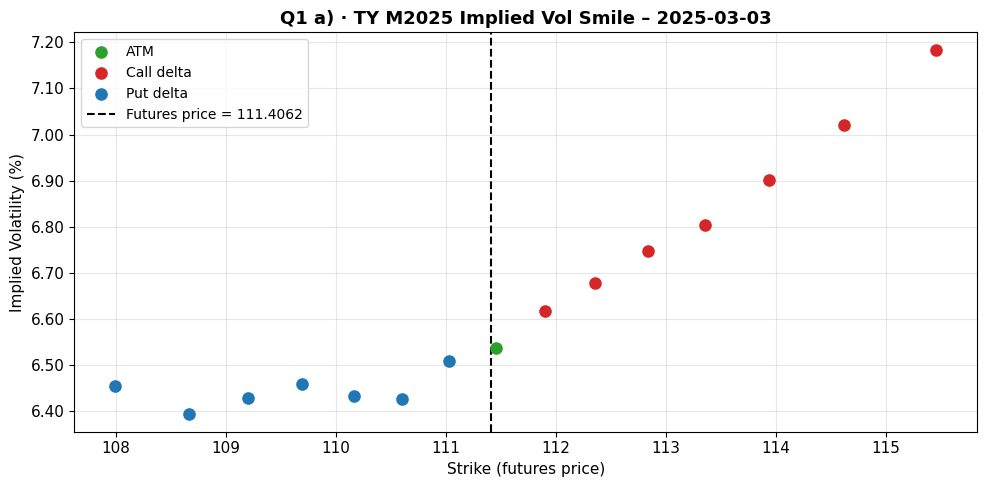

,ATM vol (avg P50/C50) [%],Strike min,Strike max,Wing spread (max–min)
0,6.5377%,107.9951,115.4536,7.4585


In [6]:
# ── Q1 helper functions (defined here; reused in Q1b, Q1c, Q2–Q5) ─────────────

def put_strike(F: float, sigma: float, T: float, q: float) -> float:
    """
    Strike for OTM put with absolute delta q = |Δ_P| = N(-d₁).
    Derivation: |Δ_P| = q  =>  d₁ = -Φ⁻¹(q)  =>  K = F·exp(Φ⁻¹(q)·σ√T + ½σ²T).
    """
    if sigma <= 0 or T <= 0 or not (0 < q < 1):
        return np.nan
    return float(F * np.exp(norm.ppf(q) * sigma * np.sqrt(T) + 0.5 * sigma**2 * T))


def call_strike(F: float, sigma: float, T: float, q: float) -> float:
    """
    Strike for OTM call with delta q = Δ_C = N(d₁).
    Derivation: Δ_C = q  =>  d₁ = Φ⁻¹(q)  =>  K = F·exp(-Φ⁻¹(q)·σ√T + ½σ²T).
    """
    if sigma <= 0 or T <= 0 or not (0 < q < 1):
        return np.nan
    return float(F * np.exp(-norm.ppf(q) * sigma * np.sqrt(T) + 0.5 * sigma**2 * T))


def atm_vol_from_row(row: pd.Series) -> float:
    """ATM vol estimate: average of P50dvol and C50dvol."""
    vals = []
    for c in ["P50dvol", "C50dvol"]:
        if c in row.index:
            v = float(row[c])
            if np.isfinite(v) and v > 0:
                vals.append(v)
    return float(np.mean(vals)) if vals else np.nan


def build_smile(row: pd.Series,
                put_cols: list = PUT_COLS,
                call_cols: list = CALL_COLS) -> pd.DataFrame:
    """
    Convert one TY surface row (delta vols) into a strike-based smile DataFrame.

    OTM convention (standard market practice):
      - Puts  with delta <= 0.50 → strike < ATM  (OTM puts, left wing)
      - Calls with delta <= 0.50 → strike > ATM  (OTM calls, right wing)
      - delta == 0.50 rows from both sides are averaged into a single ATM point

    ITM options (e.g. P85dvol, C85dvol) are excluded because:
      (1) their implied vols duplicate information already in the OTM wing,
      (2) they are illiquid and carry wider bid-ask spreads, and
      (3) including them biases the SSE calibration toward noisy strike regions.
    """
    F = float(row["Future Price"])
    T = float(row["Expiration Option"])
    records = []

    for col in put_cols:
        q = int(re.search(r"\d+", col).group()) / 100.0
        if q > 0.50:          # ITM put (delta > 50) — skip
            continue
        sigma = float(row[col])
        if not (np.isfinite(sigma) and sigma > 0):
            continue
        K = put_strike(F, sigma, T, q)
        if np.isfinite(K) and K > 0:
            records.append({"side": "P", "delta": q, "strike": K, "vol": sigma})

    for col in call_cols:
        q = int(re.search(r"\d+", col).group()) / 100.0
        if q > 0.50:          # ITM call (delta > 50) — skip
            continue
        sigma = float(row[col])
        if not (np.isfinite(sigma) and sigma > 0):
            continue
        K = call_strike(F, sigma, T, q)
        if np.isfinite(K) and K > 0:
            records.append({"side": "C", "delta": q, "strike": K, "vol": sigma})

    df = pd.DataFrame(records)
    if df.empty:
        return pd.DataFrame(columns=["side", "delta", "strike", "vol",
                                     "Future_Price", "T", "date"])

    # Merge P50/C50 into a single ATM point
    atm_mask = np.isclose(df["delta"], 0.50)
    atm_pts  = df[atm_mask]
    if len(atm_pts) >= 2:
        atm_row_df = pd.DataFrame([{
            "side": "ATM", "delta": 0.50,
            "strike": atm_pts["strike"].mean(),
            "vol":    atm_pts["vol"].mean(),
        }])
        df = pd.concat([df[~atm_mask], atm_row_df], ignore_index=True)

    df["Future_Price"] = F
    df["T"]   = T
    df["date"] = row["date"]
    return df.sort_values("strike").reset_index(drop=True)


def nearest_date(target: pd.Timestamp, available) -> pd.Timestamp:
    """Return the nearest available date to target."""
    idx = np.argmin(np.abs(pd.to_datetime(available) - target))
    return pd.Timestamp(available[idx])


# ── Build and display the early M2025 smile ───────────────────────────────────
q1a_row   = ty_option_surfaces_M2025.sort_values("date").iloc[0]
q1a_date  = q1a_row["date"]
q1a_smile = build_smile(q1a_row)
q1a_F     = float(q1a_row["Future Price"])
q1a_atm   = atm_vol_from_row(q1a_row)

# Display smile table
display(
    q1a_smile[["side", "delta", "strike", "vol"]]
    .assign(vol_pct=lambda d: (d["vol"] * 100).round(4))
    .drop(columns="vol")
    .style.set_caption(f"Q1 a) · TY M2025 Strike Smile – {q1a_date.date()}")
    .format({"strike": "{:.4f}", "vol_pct": "{:.4f}%", "delta": "{:.2f}"})
)

# Plot smile
fig, ax = plt.subplots(figsize=(10, 5))
side_colors = {"P": "#1f77b4", "C": "#d62728", "ATM": "#2ca02c"}
side_labels  = {"P": "Put delta", "C": "Call delta", "ATM": "ATM"}
for side, grp in q1a_smile.groupby("side"):
    ax.scatter(grp["strike"], grp["vol"] * 100,
               color=side_colors[side], s=65, label=side_labels[side], zorder=3)
ax.axvline(q1a_F, color="black", ls="--", lw=1.5,
           label=f"Futures price = {q1a_F:.4f}")
ax.set_title(f"Q1 a) · TY M2025 Implied Vol Smile – {q1a_date.date()}")
ax.set_xlabel("Strike (futures price)")
ax.set_ylabel("Implied Volatility (%)")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.legend()
fig.tight_layout()
plt.show()

# Summary metrics
display(pd.DataFrame({
    "ATM vol (avg P50/C50) [%]": [f"{q1a_atm*100:.4f}%"],
    "Strike min":                [f"{q1a_smile['strike'].min():.4f}"],
    "Strike max":                [f"{q1a_smile['strike'].max():.4f}"],
    "Wing spread (max–min)":     [f"{q1a_smile['strike'].max() - q1a_smile['strike'].min():.4f}"],
}).style.set_caption("Q1 a) · TY M2025 ATM Vol and Strike Range"))

### Q1 b) – Smile Evolution Around the April 2025 Tariff Episode

Three dates chosen around the April 2025 tariff shock (as studied in C.8.1):

| Label | Date | Event |
|---|---|---|
| Before (Apr 2) | 2025-04-02 | Day before Liberation Day tariff announcement |
| Shock (Apr 3)  | 2025-04-03 | Liberation Day: broad tariffs announced, flight-to-safety bid |
| Pause (Apr 9)  | 2025-04-09 | 90-day tariff pause; yields reversed sharply |

We compare both the **level** (ATM vol) and the **shape** (skew via 25Δ RR,
curvature via 25Δ Butterfly) across the three dates.

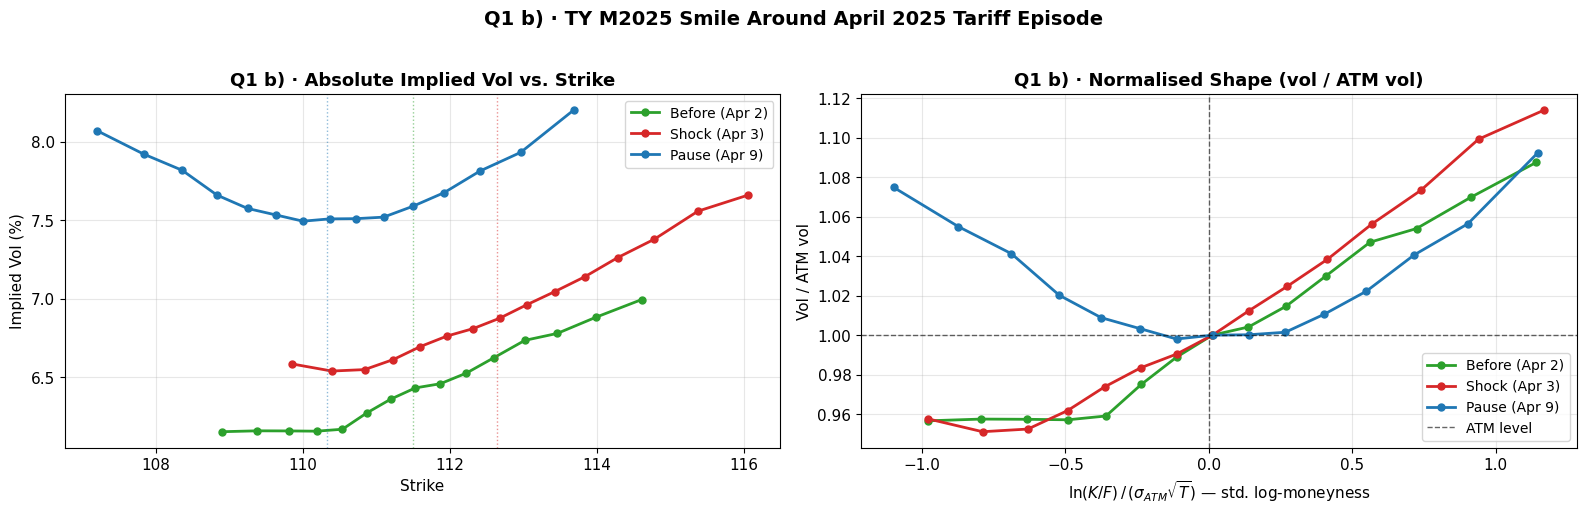

,Date,Futures Price,ATM Vol (%),25Δ RR = P25–C25 (vol%),25Δ Butterfly (vol%)
Event,,,,,
Before (Apr 2),2025-04-02,111.500000,6.432600,-0.621300,0.036600
Shock (Apr 3),2025-04-03,112.640625,6.876200,-0.830700,0.088500
Pause (Apr 9),2025-04-09,110.328125,7.509400,0.004600,0.307400


In [7]:
TARIFF_DATES = {
    "Before (Apr 2)": pd.Timestamp("2025-04-02"),
    "Shock (Apr 3)":  pd.Timestamp("2025-04-03"),
    "Pause (Apr 9)":  pd.Timestamp("2025-04-09"),
}
_avail_M2025 = ty_option_surfaces_M2025["date"].sort_values().values

# Build smiles for each tariff event
tariff_smiles = {}
tariff_rows   = {}
for label, target in TARIFF_DATES.items():
    dt  = nearest_date(target, _avail_M2025)
    row = ty_option_surfaces_M2025[ty_option_surfaces_M2025["date"] == dt].iloc[0]
    tariff_smiles[label] = build_smile(row)
    tariff_rows[label]   = row

# ── Panel plots: absolute vol and normalised shape ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
PALETTE = ["#2ca02c", "#d62728", "#1f77b4"]

# Left: absolute implied vol vs. strike
ax = axes[0]
for (label, smile), color in zip(tariff_smiles.items(), PALETTE):
    row = tariff_rows[label]
    ax.plot(smile["strike"], smile["vol"] * 100, "o-",
            color=color, lw=2, ms=5, label=label)
    ax.axvline(float(row["Future Price"]), color=color, ls=":", lw=1, alpha=0.5)
ax.set_title("Q1 b) · Absolute Implied Vol vs. Strike")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Vol (%)")
ax.legend()

# Right: normalised shape — vol/σ_ATM vs. standardised log-moneyness
ax = axes[1]
for (label, smile), color in zip(tariff_smiles.items(), PALETTE):
    row   = tariff_rows[label]
    F_    = float(row["Future Price"])
    sig_  = atm_vol_from_row(row)
    T_    = float(row["Expiration Option"])
    x = np.log(smile["strike"] / F_) / (sig_ * np.sqrt(T_))
    y = smile["vol"] / sig_
    ax.plot(x, y, "o-", color=color, lw=2, ms=5, label=label)
ax.axhline(1, color="black", ls="--", lw=1, alpha=0.6, label="ATM level")
ax.axvline(0, color="black", ls="--", lw=1, alpha=0.6)
ax.set_title("Q1 b) · Normalised Shape (vol / ATM vol)")
ax.set_xlabel(r"$\ln(K/F)\,/\,(\sigma_{ATM}\sqrt{T})$ — std. log-moneyness")
ax.set_ylabel("Vol / ATM vol")
ax.legend()

fig.suptitle("Q1 b) · TY M2025 Smile Around April 2025 Tariff Episode",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# ── Smile characteristics table ───────────────────────────────────────────────
recs = []
for label, row in tariff_rows.items():
    atm  = atm_vol_from_row(row)
    p25  = float(row["P25dvol"]) if "P25dvol" in row.index else np.nan
    c25  = float(row["C25dvol"]) if "C25dvol" in row.index else np.nan
    rr25  = (p25 - c25) * 100           if np.isfinite(p25) and np.isfinite(c25) else np.nan
    fly25 = ((p25 + c25) / 2 - atm) * 100 if np.isfinite(p25) and np.isfinite(c25) else np.nan
    recs.append({
        "Event":              label,
        "Date":               row["date"].date(),
        "Futures Price":      round(float(row["Future Price"]), 6),
        "ATM Vol (%)":        round(atm * 100, 4),
        "25Δ RR = P25–C25 (vol%)": round(rr25,  4) if np.isfinite(rr25)  else np.nan,
        "25Δ Butterfly (vol%)":    round(fly25, 4) if np.isfinite(fly25) else np.nan,
    })

display(
    pd.DataFrame(recs).set_index("Event")
    .style.set_caption("Q1 b) · Smile Characteristics Around Tariff Episode")
)

ATM vol rises across the three dates (6.4326% → 6.8762% → 7.5094%), but the more informative change is in *skew vs. curvature*:

- **Before → Shock (Apr 2 → Apr 3): a skew move.** The 25Δ risk-reversal becomes more negative (RR = P25 − C25: −0.6213 → −0.8307 vol-pp), meaning the **call wing richens relative to the put wing** (a more pronounced right-wing / “price-up” tail). Curvature rises only modestly (25Δ fly: 0.0366 → 0.0885), so this is primarily a **wing-asymmetry repricing**, not a symmetric fattening of both tails.

- **Shock → Pause (Apr 3 → Apr 9): a curvature move.** The risk-reversal collapses to ~flat (−0.8307 → +0.0046), but the butterfly **jumps sharply** (0.0885 → 0.3074). In the normalised shape plot, this shows up as **both wings lifting relative to ATM**, i.e., a much more convex, U‑shaped smile: the market shifts from directional tail pricing to **two-sided uncertainty** priced in the wings.

### Q1 c) – TY Futures Options vs. 1Yx5Y Swaptions: Normalised Smile Comparison

Since TY options and swaptions have very different ATM levels (~111 futures price vs.
~3.35–3.57% yield), a raw vol comparison is meaningless. We normalise:

- **y-axis**: $\sigma / \sigma_{ATM}$ — removes level, isolates smile shape
- **x-axis**: $\ln(K/F) / (\sigma_{ATM}\sqrt{T})$ — standardised log-moneyness in σ units

This common grid reveals differences in **skew** (ρ-driven left/right asymmetry) and
**curvature** (ν-driven wing fatness) across the two markets.

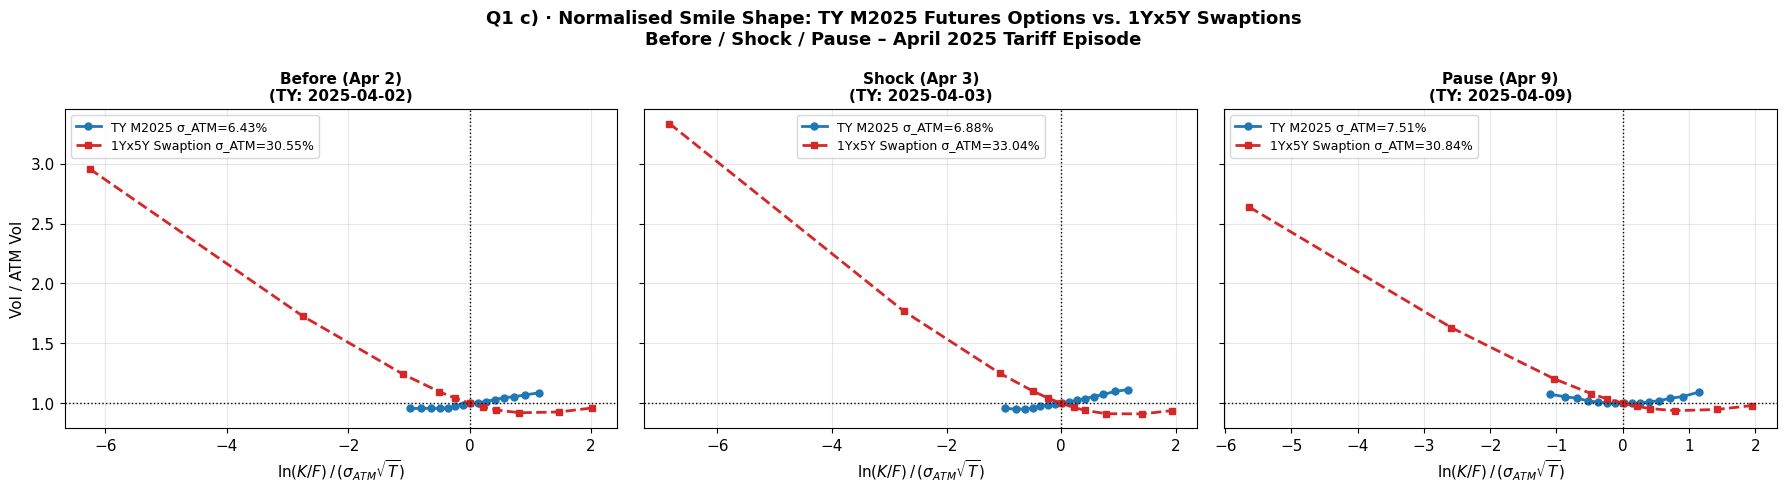

,TY Date,SW Date,TY ATM Vol (%),SW ATM Vol (%),TY Norm 25Δ RR,SW Norm 25Δ RR,TY Norm 25Δ Fly,SW Norm 25Δ Fly
Event,,,,,,,,
Before (Apr 2),2025-04-02,2025-04-02,6.4326,30.5500,-0.0966,0.0753,0.0057,0.0049
Shock (Apr 3),2025-04-03,2025-04-03,6.8762,33.0400,-0.1208,0.0790,0.0129,0.0050
Pause (Apr 9),2025-04-09,2025-04-09,7.5094,30.8400,0.0006,0.0616,0.0409,0.0045


In [8]:
# ── Swaption helper (defined here; reused in Q4) ──────────────────────────────
_sw_mono_cols = [c for c in swaption_smile_black_vol_pct.columns if c != "date"]


def _find_sw_atm_col(cols: list) -> str:
    """Return the column whose integer moneyness value is 0 (ATM)."""
    for c in cols:
        try:
            if int(c) == 0:
                return c
        except (ValueError, TypeError):
            pass
    raise KeyError("Cannot find ATM (moneyness=0) column in swaption vol data.")


_sw_atm_col = _find_sw_atm_col(_sw_mono_cols)


def build_sw_smile_arrays(dt: pd.Timestamp):
    """
    Return (strikes_dec, vols_dec, F_dec, T, atm_vol_dec) for one swaption date.
    Vols are divided by 100 from the % sheet. T = 1.0 yr for 1Yx5Y.
    """
    vr = swaption_smile_black_vol_pct[swaption_smile_black_vol_pct["date"] == dt].iloc[0]
    fr = swaption_smile_atm_forward[swaption_smile_atm_forward["date"] == dt].iloc[0]
    sr = swaption_smile_abs_strike_pct[swaption_smile_abs_strike_pct["date"] == dt].iloc[0]
    strikes  = np.array([float(sr[c]) / 100.0 for c in _sw_mono_cols], dtype=float)
    vols     = np.array([float(vr[c]) / 100.0 for c in _sw_mono_cols], dtype=float)
    F        = float(fr["atm_fwd_pct"]) / 100.0
    atm_vol  = float(vr[_sw_atm_col]) / 100.0
    return strikes, vols, F, 1.0, atm_vol   # T = 1 year


# ── Three-panel normalised overlay: Before / Shock / Pause ────────────────────
EVENT_LABELS = list(TARIFF_DATES.keys())
_sw_avail    = swaption_smile_black_vol_pct["date"].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
comp_records = []

for ax, label in zip(axes, EVENT_LABELS):
    ty_dt   = nearest_date(TARIFF_DATES[label], _avail_M2025)
    ty_r    = ty_option_surfaces_M2025[ty_option_surfaces_M2025["date"] == ty_dt].iloc[0]
    ty_sm   = build_smile(ty_r)
    ty_F_   = float(ty_r["Future Price"])
    ty_T_   = float(ty_r["Expiration Option"])
    ty_atm_ = atm_vol_from_row(ty_r)

    ty_x = np.log(ty_sm["strike"] / ty_F_) / (ty_atm_ * np.sqrt(ty_T_))
    ty_y = ty_sm["vol"] / ty_atm_
    ax.plot(ty_x, ty_y, "o-", color="#1f77b4", lw=2, ms=5,
            label=f"TY M2025 σ_ATM={ty_atm_*100:.2f}%")

    # Swaption — match nearest available date (tolerance ≤ 2 days)
    sw_dt   = nearest_date(ty_dt, _sw_avail)
    has_sw  = abs((sw_dt - ty_dt).days) <= 2
    if has_sw:
        sw_K_, sw_v_, sw_F_, sw_T_, sw_atm_ = build_sw_smile_arrays(sw_dt)
        sw_x = np.log(sw_K_ / sw_F_) / (sw_atm_ * np.sqrt(sw_T_))
        sw_y = sw_v_ / sw_atm_
        ax.plot(sw_x, sw_y, "s--", color="#d62728", lw=2, ms=5,
                label=f"1Yx5Y Swaption σ_ATM={sw_atm_*100:.2f}%")

        # Shape metrics
        p25_v = ty_sm.loc[(ty_sm["side"] == "P") & ty_sm["delta"].between(0.249, 0.251), "vol"]
        c25_v = ty_sm.loc[(ty_sm["side"] == "C") & ty_sm["delta"].between(0.249, 0.251), "vol"]
        ty_rr  = ((p25_v.mean() - c25_v.mean()) / ty_atm_
                  if (len(p25_v) > 0 and len(c25_v) > 0) else np.nan)
        ty_fly = (((p25_v.mean() + c25_v.mean()) / 2 - ty_atm_) / ty_atm_
                  if (len(p25_v) > 0 and len(c25_v) > 0) else np.nan)

        sw_atm_abs = sw_F_
        sw_v_m25 = float(np.interp(sw_atm_abs - 0.0025, sw_K_, sw_v_))
        sw_v_p25 = float(np.interp(sw_atm_abs + 0.0025, sw_K_, sw_v_))
        sw_rr    = (sw_v_m25 - sw_v_p25) / sw_atm_
        sw_fly   = ((sw_v_m25 + sw_v_p25) / 2 - sw_atm_) / sw_atm_
    else:
        sw_atm_ = np.nan
        ty_rr = ty_fly = sw_rr = sw_fly = np.nan

    comp_records.append({
        "Event":           label,
        "TY Date":         ty_dt.date(),
        "SW Date":         sw_dt.date() if has_sw else "n/a",
        "TY ATM Vol (%)":  round(ty_atm_ * 100, 4),
        "SW ATM Vol (%)":  round(sw_atm_ * 100, 4) if has_sw else np.nan,
        "TY Norm 25Δ RR":  round(ty_rr,  4) if np.isfinite(ty_rr)  else np.nan,
        "SW Norm 25Δ RR":  round(sw_rr,  4) if np.isfinite(sw_rr)  else np.nan,
        "TY Norm 25Δ Fly": round(ty_fly, 4) if np.isfinite(ty_fly) else np.nan,
        "SW Norm 25Δ Fly": round(sw_fly, 4) if np.isfinite(sw_fly) else np.nan,
    })

    ax.axhline(1, color="black", ls=":", lw=1)
    ax.axvline(0, color="black", ls=":", lw=1)
    ax.set_title(f"{label.strip()}\n(TY: {ty_dt.date()})", fontsize=11)
    ax.set_xlabel(r"$\ln(K/F)\,/\,(\sigma_{ATM}\sqrt{T})$")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Vol / ATM Vol")
fig.suptitle(
    "Q1 c) · Normalised Smile Shape: TY M2025 Futures Options vs. 1Yx5Y Swaptions\n"
    "Before / Shock / Pause – April 2025 Tariff Episode",
    fontsize=13, fontweight="bold"
)
fig.tight_layout()
plt.show()

# Shape-metrics comparison table
display(
    pd.DataFrame(comp_records).set_index("Event")
    .style.set_caption(
        "Q1 c) · Smile Shape Metrics: TY Options vs. 1Yx5Y Swaptions\n"
        "(Norm. RR = (P25–C25)/σ_ATM;  Norm. Fly = (avg wing – ATM)/σ_ATM)"
    )
    .format({c: "{:.4f}" for c in [
        "TY ATM Vol (%)","SW ATM Vol (%)",
        "TY Norm 25Δ RR","SW Norm 25Δ RR",
        "TY Norm 25Δ Fly","SW Norm 25Δ Fly"]}, na_rep="n/a")
)

Yes — even after normalising by ATM vol, the two products show clear and persistent **shape** differences.

- **Skew (25Δ RR): sign is opposite.** On Apr 2 and Apr 3, TY has *negative* normalised RR (−0.0966, −0.1208), while the 1Yx5Y swaption has *positive* normalised RR (+0.0753, +0.0790). Interpreting RR = P25 − C25, this means TY’s **call wing is richer** (right-wing elevated in price space), whereas swaptions’ **put wing is richer** (left-wing elevated in rate space). On Apr 9, TY’s RR is essentially flat (+0.0006) but swaptions remain positively skewed (+0.0616).

- **Curvature (25Δ Fly): TY is far more convex and regime-sensitive.** TY’s normalised fly rises from 0.0057 (Apr 2) → 0.0129 (Apr 3) → 0.0409 (Apr 9), while the swaption fly stays near-constant and small (0.0049 → 0.0050 → 0.0045). Visually, TY develops a much more pronounced U-shape after the pause (both wings expensive relative to ATM), whereas the swaption smile remains predominantly skew-driven with limited curvature.

Note: TY vols are quoted on **futures price**, while swaption vols are quoted on **swap rates**. Because price and yield move inversely (and price-vol scales roughly like Duration × Forward Rate × rate-vol), cross-product skew/ρ comparisons are not apples-to-apples; the skew sign can flip mechanically under the price↔rate mapping.

## Question 2 – SABR Calibration

We calibrate the SABR model ($\beta = 0.5$ fixed) to the TY futures option smile.

**SABR formula (Hagan et al. 2002):**

$$
\sigma_B(K,F) = \frac{\alpha}{(FK)^{(1-\beta)/2}\cdot D}\cdot\frac{z}{\chi(z)}\cdot
\left[1 + \Lambda\cdot T\right]
$$

where:
$$z = \frac{\nu}{\alpha}(FK)^{(1-\beta)/2}\ln\!\left(\frac{F}{K}\right), \quad
\chi(z) = \ln\!\left(\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}\right)$$

$$D = 1 + \frac{(1-\beta)^2}{24}\ln^2\!\frac{F}{K} + \frac{(1-\beta)^4}{1920}\ln^4\!\frac{F}{K}$$

$$\Lambda = \frac{(1-\beta)^2\alpha^2}{24(FK)^{1-\beta}}
          + \frac{\rho\beta\nu\alpha}{4(FK)^{(1-\beta)/2}}
          + \frac{2-3\rho^2}{24}\nu^2$$

**Calibration strategy:** Fix $\beta = 0.5$.
At each trial $(\nu, \rho)$, solve analytically for $\alpha$ from the ATM constraint
$\sigma_{SABR}(F,F) = \sigma_{ATM}$. This reduces the optimisation to a 2-parameter
SSE minimisation over $(\nu, \rho)$.

### Q2 a) – SABR Calibration on the Representative Early Date (2025-03-03)

We calibrate SABR (β=0.5) to the TY M2025 smile, overlay the fitted curve on market
data, and report parameters and residuals.

,Date,Contract,α (alpha),β (beta),ρ (rho),ν (nu),σ_ATM (%),RMSE (vol%),Success
0,2025-03-03,M2025,0.677681,0.500000,0.247978,1.027732,6.537700,0.021140,True


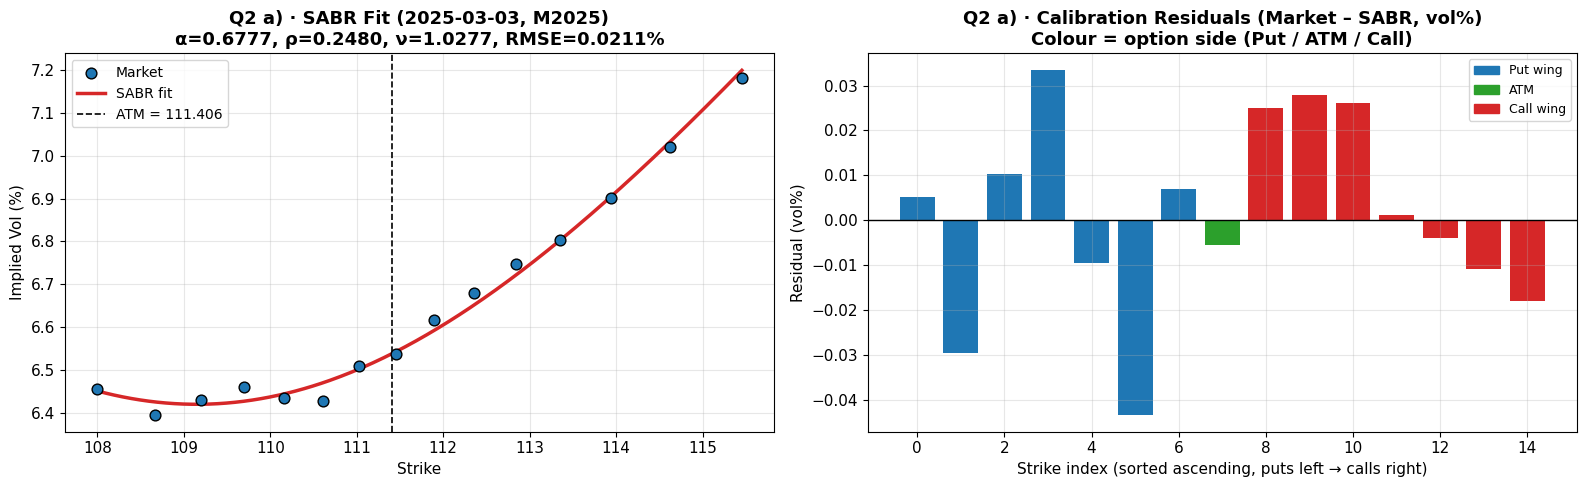

In [9]:
# ── SABR core functions (defined here; used in Q2–Q5) ─────────────────────────

def sabr_atm_vol(F: float, T: float,
                 alpha: float, beta: float, rho: float, nu: float) -> float:
    """Hagan ATM SABR vol – exact limit as K → F."""
    omB = 1.0 - beta
    Fb  = F ** omB
    lam = (
        omB**2 / 24.0 * alpha**2 / F**(2 * omB)
        + rho * beta * nu * alpha / (4.0 * Fb)
        + (2.0 - 3.0 * rho**2) / 24.0 * nu**2
    )
    return (alpha / Fb) * (1.0 + lam * T)


def sabr_implied_vol(F: float, K: float, T: float,
                     alpha: float, beta: float, rho: float, nu: float) -> float:
    """Hagan et al. 2002 lognormal SABR vol approximation."""
    if alpha <= 0 or nu <= 0 or not (-1 < rho < 1) or T <= 0:
        return np.nan
    omB   = 1.0 - beta
    logFK = np.log(F / K)

    # ATM limit (avoid division by zero)
    if abs(logFK) < 1e-10:
        return sabr_atm_vol(F, T, alpha, beta, rho, nu)

    FK_mid = (F * K) ** (omB / 2.0)
    z      = (nu / alpha) * FK_mid * logFK
    inner  = max(1.0 - 2.0 * rho * z + z**2, 1e-16)
    chi    = np.log((np.sqrt(inner) + z - rho) / (1.0 - rho))
    z_over_chi = (z / chi) if abs(chi) > 1e-12 else 1.0

    D = 1.0 + omB**2 / 24.0 * logFK**2 + omB**4 / 1920.0 * logFK**4
    lam = (
        omB**2 / 24.0 * alpha**2 / (F * K)**omB
        + rho * beta * nu * alpha / (4.0 * FK_mid)
        + (2.0 - 3.0 * rho**2) / 24.0 * nu**2
    )
    return (alpha / (FK_mid * D)) * z_over_chi * (1.0 + lam * T)


def solve_alpha(sigma_atm: float, F: float, T: float,
                beta: float, rho: float, nu: float) -> float:
    """Solve σ_SABR(F,F; α,β,ρ,ν) = sigma_atm for α via Brent's method."""
    if sigma_atm <= 0 or F <= 0 or T <= 0:
        return np.nan
    guess = sigma_atm * F ** (1.0 - beta)

    def f(a: float) -> float:
        return sabr_atm_vol(F, T, a, beta, rho, nu) - sigma_atm

    lo, hi = 1e-9, max(20.0 * guess, 5.0)
    try:
        if f(lo) * f(hi) > 0:
            for _ in range(60):
                hi *= 2.0
                if f(lo) * f(hi) < 0:
                    break
            else:
                return np.nan
        return float(brentq(f, lo, hi, maxiter=500, xtol=1e-10))
    except Exception:
        return np.nan


def calibrate_sabr(smile_df: pd.DataFrame, beta: float = BETA,
                   n_starts: int = 4) -> dict:
    """
    Calibrate SABR (β fixed) to a strike-based smile DataFrame.
    Parametrises ν = exp(x0), ρ = tanh(x1) to enforce domain constraints.
    Multiple random restarts avoid local minima.

    Returns dict with keys: alpha, beta, rho, nu, rmse, sigma_atm, success,
                            strikes, vols, fitted.
    """
    sub = smile_df.dropna(subset=["strike", "vol"]).copy()
    sub = sub[(sub["strike"] > 0) & (sub["vol"] > 0)].sort_values("strike")
    strikes = sub["strike"].to_numpy(dtype=float)
    vols    = sub["vol"].to_numpy(dtype=float)

    sides = sub["side"].to_numpy() if "side" in sub.columns else np.array(["?"] * len(strikes))

    if len(strikes) < 4:
        return {"alpha": np.nan, "beta": beta, "rho": np.nan, "nu": np.nan,
                "rmse": np.nan, "sigma_atm": np.nan, "success": False,
                "strikes": strikes, "vols": vols, "sides": sides,
                "fitted": np.full(len(strikes), np.nan)}

    F     = float(sub["Future_Price"].iloc[0])
    T     = float(sub["T"].iloc[0])

    # ATM vol: prefer explicit ATM row; else interpolate at F
    atm_pts   = sub[sub["side"] == "ATM"] if "side" in sub.columns else pd.DataFrame()
    sigma_atm = (float(atm_pts["vol"].iloc[0]) if len(atm_pts) > 0
                 else float(np.interp(F, strikes, vols)))

    # Objective: SSE in vol space (α solved analytically from ATM constraint)
    def objective(x: np.ndarray) -> float:
        nu  = np.exp(x[0])
        rho = np.tanh(x[1])
        a   = solve_alpha(sigma_atm, F, T, beta, rho, nu)
        if not np.isfinite(a) or a <= 0:
            return 1e9
        fitted = np.array([sabr_implied_vol(F, k, T, a, beta, rho, nu) for k in strikes])
        if not np.all(np.isfinite(fitted)):
            return 1e9
        return float(np.sum((fitted - vols)**2))

    # Multiple restarts: informed start + random
    rng = np.random.default_rng(42)
    x0s = [np.array([np.log(0.30), np.arctanh(-0.20)])]
    x0s += [np.array([np.log(rng.uniform(0.1, 2.0)),
                       np.arctanh(rng.uniform(-0.80, 0.80))])
            for _ in range(n_starts - 1)]

    best, best_val = None, np.inf
    for x0 in x0s:
        try:
            res = minimize(objective, x0, method="L-BFGS-B",
                           options={"maxiter": 800, "ftol": 1e-13})
            if res.fun < best_val:
                best_val = res.fun
                best     = res
        except Exception:
            pass

    if best is None or best_val > 1e8:
        return {"alpha": np.nan, "beta": beta, "rho": np.nan, "nu": np.nan,
                "rmse": np.nan, "sigma_atm": sigma_atm, "success": False,
                "strikes": strikes, "vols": vols, "sides": sides,
                "fitted": np.full(len(strikes), np.nan)}

    nu_hat  = np.exp(best.x[0])
    rho_hat = np.tanh(best.x[1])
    a_hat   = solve_alpha(sigma_atm, F, T, beta, rho_hat, nu_hat)
    fitted  = np.array([sabr_implied_vol(F, k, T, a_hat, beta, rho_hat, nu_hat)
                        for k in strikes])
    rmse = float(np.sqrt(np.mean((fitted - vols)**2)))

    return {
        "alpha": a_hat, "beta": beta, "rho": rho_hat, "nu": nu_hat,
        "rmse": rmse, "sigma_atm": sigma_atm,
        "success": bool(np.isfinite(a_hat)),
        "strikes": strikes, "vols": vols, "sides": sides, "fitted": fitted,
    }


# ── Calibrate on the representative early date ────────────────────────────────
q2a_calib = calibrate_sabr(q1a_smile)

# Parameter table
display(pd.DataFrame([{
    "Date":        q1a_date.date(),
    "Contract":    "M2025",
    "α (alpha)":   round(q2a_calib["alpha"], 6),
    "β (beta)":    round(q2a_calib["beta"],  2),
    "ρ (rho)":     round(q2a_calib["rho"],   6),
    "ν (nu)":      round(q2a_calib["nu"],    6),
    "σ_ATM (%)":   round(q2a_calib["sigma_atm"] * 100, 4),
    "RMSE (vol%)": round(q2a_calib["rmse"]   * 100, 5),
    "Success":     q2a_calib["success"],
}]).style.set_caption("Q2 a) · SABR Parameters – Representative Date"))

# ── Overlay plot + residuals ───────────────────────────────────────────────────
K_grid = np.linspace(q2a_calib["strikes"].min(),
                     q2a_calib["strikes"].max(), 300)
sigma_grid = np.array([
    sabr_implied_vol(q1a_F, k, float(q1a_row["Expiration Option"]),
                     q2a_calib["alpha"], BETA,
                     q2a_calib["rho"], q2a_calib["nu"])
    for k in K_grid
])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.scatter(q2a_calib["strikes"], q2a_calib["vols"] * 100,
           s=60, color="#1f77b4", edgecolors="black", zorder=4, label="Market")
ax.plot(K_grid, sigma_grid * 100, "-", color="#d62728", lw=2.5, label="SABR fit")
ax.axvline(q1a_F, color="black", ls="--", lw=1.2, label=f"ATM = {q1a_F:.3f}")
ax.set_title(f"Q2 a) · SABR Fit ({q1a_date.date()}, M2025)\n"
             f"α={q2a_calib['alpha']:.4f}, ρ={q2a_calib['rho']:.4f}, "
             f"ν={q2a_calib['nu']:.4f}, RMSE={q2a_calib['rmse']*100:.4f}%")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Vol (%)")
ax.legend()

ax = axes[1]
resid = (q2a_calib["vols"] - q2a_calib["fitted"]) * 100
_side_color_map = {"P": "#1f77b4", "C": "#d62728", "ATM": "#2ca02c", "?": "#888888"}
bar_colors = [_side_color_map.get(s, "#888888") for s in q2a_calib["sides"]]
ax.bar(range(len(resid)), resid, color=bar_colors)
ax.axhline(0, color="black", lw=1)
# Legend patches for side coloring
from matplotlib.patches import Patch
legend_patches = [
    Patch(color="#1f77b4", label="Put wing"),
    Patch(color="#2ca02c", label="ATM"),
    Patch(color="#d62728", label="Call wing"),
]
ax.legend(handles=legend_patches, fontsize=9)
ax.set_title("Q2 a) · Calibration Residuals (Market – SABR, vol%)\n"
             "Colour = option side (Put / ATM / Call)")
ax.set_xlabel("Strike index (sorted ascending, puts left → calls right)")
ax.set_ylabel("Residual (vol%)")
fig.tight_layout()
plt.show()

### Q2 b) & Q2 c) – Daily SABR Calibration: All Three Contracts

We calibrate SABR for every trading day in M2025, H2026, and M2026.
We record $(α, ρ, ν, σ_{ATM}, \text{RMSE})$ daily, then plot time-series and
report summary statistics per contract.

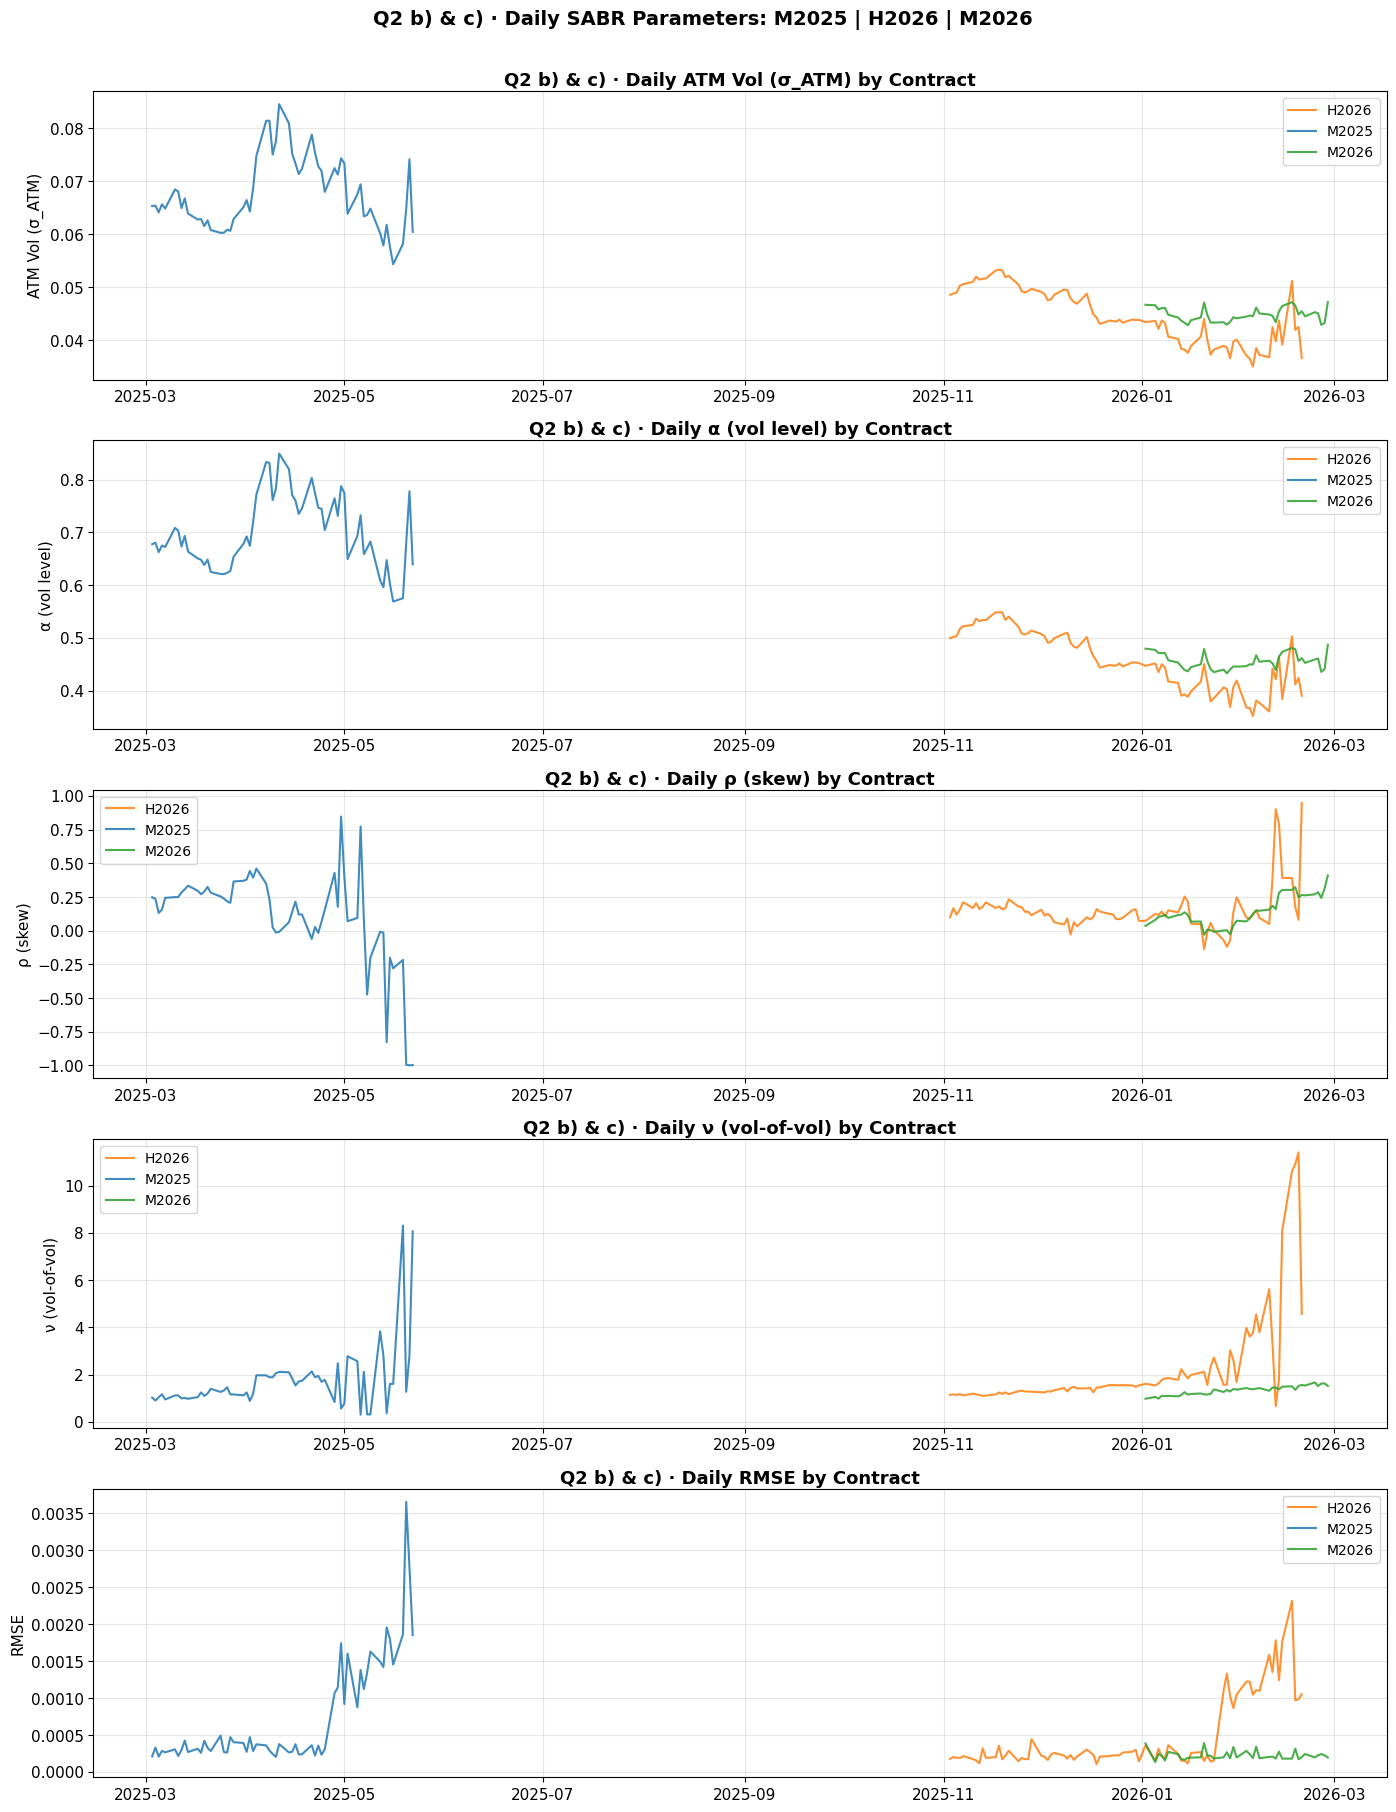

,date,contract,alpha,rho,nu,rmse_bp,sigma_atm_pct
134,2025-05-20 00:00:00,M2025,0.680265,-0.995674,1.275231,36.539183,6.475750
135,2025-05-21 00:00:00,M2025,0.777956,-0.999857,2.816388,27.644241,7.418400
74,2026-02-16 00:00:00,H2026,0.502745,0.391052,10.619030,23.126424,5.121900
130,2025-05-14 00:00:00,M2025,0.647498,-0.827818,0.368837,19.559441,6.181150
133,2025-05-19 00:00:00,M2025,0.575338,-0.216729,8.313163,18.611681,5.819850
136,2025-05-22 00:00:00,M2025,0.639589,-0.997662,8.065507,18.515988,6.047700
131,2025-05-15 00:00:00,M2025,0.602670,-0.200777,1.609340,17.976372,5.765600
71,2026-02-11 00:00:00,H2026,0.421930,0.901661,0.669751,17.808959,3.981350
73,2026-02-13 00:00:00,H2026,0.384294,0.391473,8.109780,17.647875,3.914600
120,2025-04-30 00:00:00,M2025,0.787651,0.847499,0.564354,17.412896,7.436500


In [10]:
def calibrate_contract(df_surface: pd.DataFrame, beta: float = BETA) -> pd.DataFrame:
    """Run daily SABR calibration for one contract surface DataFrame."""
    results = []
    for _, row in df_surface.sort_values("date").iterrows():
        smile = build_smile(row)
        calib = calibrate_sabr(smile, beta=beta)
        results.append({
            "date":      row["date"],
            "contract":  row.get("contract", ""),
            "F":         float(row["Future Price"]),
            "T":         float(row["Expiration Option"]),
            "sigma_atm": calib["sigma_atm"],
            "alpha":     calib["alpha"],
            "beta":      calib["beta"],
            "rho":       calib["rho"],
            "nu":        calib["nu"],
            "rmse":      calib["rmse"],
            "success":   calib["success"],
        })
    return pd.DataFrame(results)


# Daily calibration for all contracts
sabr_M2025 = calibrate_contract(ty_option_surfaces_M2025)
sabr_H2026 = calibrate_contract(ty_option_surfaces_H2026)
sabr_M2026 = calibrate_contract(ty_option_surfaces_M2026)

# Combine
sabr_all = (pd.concat([sabr_M2025, sabr_H2026, sabr_M2026], ignore_index=True)
            .sort_values(["contract", "date"])
            .reset_index(drop=True))

# ── Summary statistics table (Q2 b) ──────────────────────────────────────────
summary = (sabr_all.groupby("contract")[["sigma_atm", "alpha", "rho", "nu", "rmse"]]
           .agg(["mean", "std", "min", "max"]).round(6))
display(summary.style.set_caption("Q2 b) · SABR Parameter Summary Statistics by Contract"))

# ── Time-series plots (Q2 b) ──────────────────────────────────────────────────
param_labels = {
    "sigma_atm": "ATM Vol (σ_ATM)",
    "alpha":     "α (vol level)",
    "rho":       "ρ (skew)",
    "nu":        "ν (vol-of-vol)",
    "rmse":      "RMSE",
}

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=False)
for ax, (param, plabel) in zip(axes, param_labels.items()):
    for contract, grp in sabr_all.groupby("contract"):
        ax.plot(grp["date"], grp[param],
                color=CMAP[contract], lw=1.5, alpha=0.85, label=contract)
    ax.set_ylabel(plabel)
    ax.set_title(f"Q2 b) & c) · Daily {plabel} by Contract", pad=4)
    ax.legend(loc="best")
fig.suptitle("Q2 b) & c) · Daily SABR Parameters: M2025 | H2026 | M2026",
             fontsize=14, fontweight="bold", y=1.005)
fig.tight_layout()
plt.show()

# ── Q2 c: Worst-fit dates ─────────────────────────────────────────────────────
worst = (sabr_all.nlargest(10, "rmse")
         [["date", "contract", "sigma_atm", "rmse", "alpha", "rho", "nu"]]
         .assign(rmse_bp=lambda d: d["rmse"] * 10_000,
                 sigma_atm_pct=lambda d: d["sigma_atm"] * 100)
         .drop(columns=["rmse", "sigma_atm"]))
display(worst.style.set_caption("Q2 c) · 10 Worst Calibration Days (highest RMSE)"))

#### Dates / contracts with notably worse fit

The worst SABR fits are **not random**: they cluster in specific contracts and windows.

- **Concentration by contract.** 7 of the 10 worst-RMSE observations are in **M2025** (mostly mid/late May 2025), and the remaining 3 are in **H2026** (mid-February 2026). **M2026 does not appear** in the worst-10 list, indicating a materially more stable fit over its shorter sample.

- **Near-expiry breakdown dominates.** The two worst days are **M2025 on 2025‑05‑20 (36.54 bp)** and **2025‑05‑21 (27.64 bp)**, immediately before the M2025 sample ends (2025‑05‑22). On these days, the calibration pushes **ρ to the boundary** (−0.996 and −1.000). The H2026 worst cluster (e.g., **2026‑02‑16: 23.13 bp**) also occurs just ahead of the H2026 end date (2026‑02‑19) and coincides with **extreme ν** (ν = 10.62 on 2026‑02‑16).

**Interpretation.** The notably worse fits are primarily a **time-to-expiry / microstructure** phenomenon: as expiry approaches, wing quotes tend to be noisier and the smile becomes harder to represent with a smooth low-dimensional SABR parameterisation, so the optimizer compensates by driving **(ρ, ν)** to extreme values. In practice, SABR fits in the final weeks of a contract should be treated with extra caution.


### Additional: Visualizing SABR Model Fits on the 3 Worst Calibration Days
 
To further investigate the SABR model's limitations, we plot detailed fit diagnostics for the 3 days with the highest calibration RMSE. This allows us to see exactly how the model struggled to fit the observed smile and where residuals are most severe.
 
The following panels show, for each of these critical dates:
 - **Left:** SABR fit vs. observed option vols across strikes
 - **Right:** Fit residuals (model minus market) for puts, calls, and at-the-money options

,date,contract,sigma_atm_pct,rmse_bp,F,T
0,2025-05-20 00:00:00,M2025,6.475750,36.539183,110.203125,0.008795
1,2025-05-21 00:00:00,M2025,7.418400,27.644241,109.500000,0.006055
2,2026-02-16 00:00:00,H2026,5.121900,23.126424,113.171875,0.011534


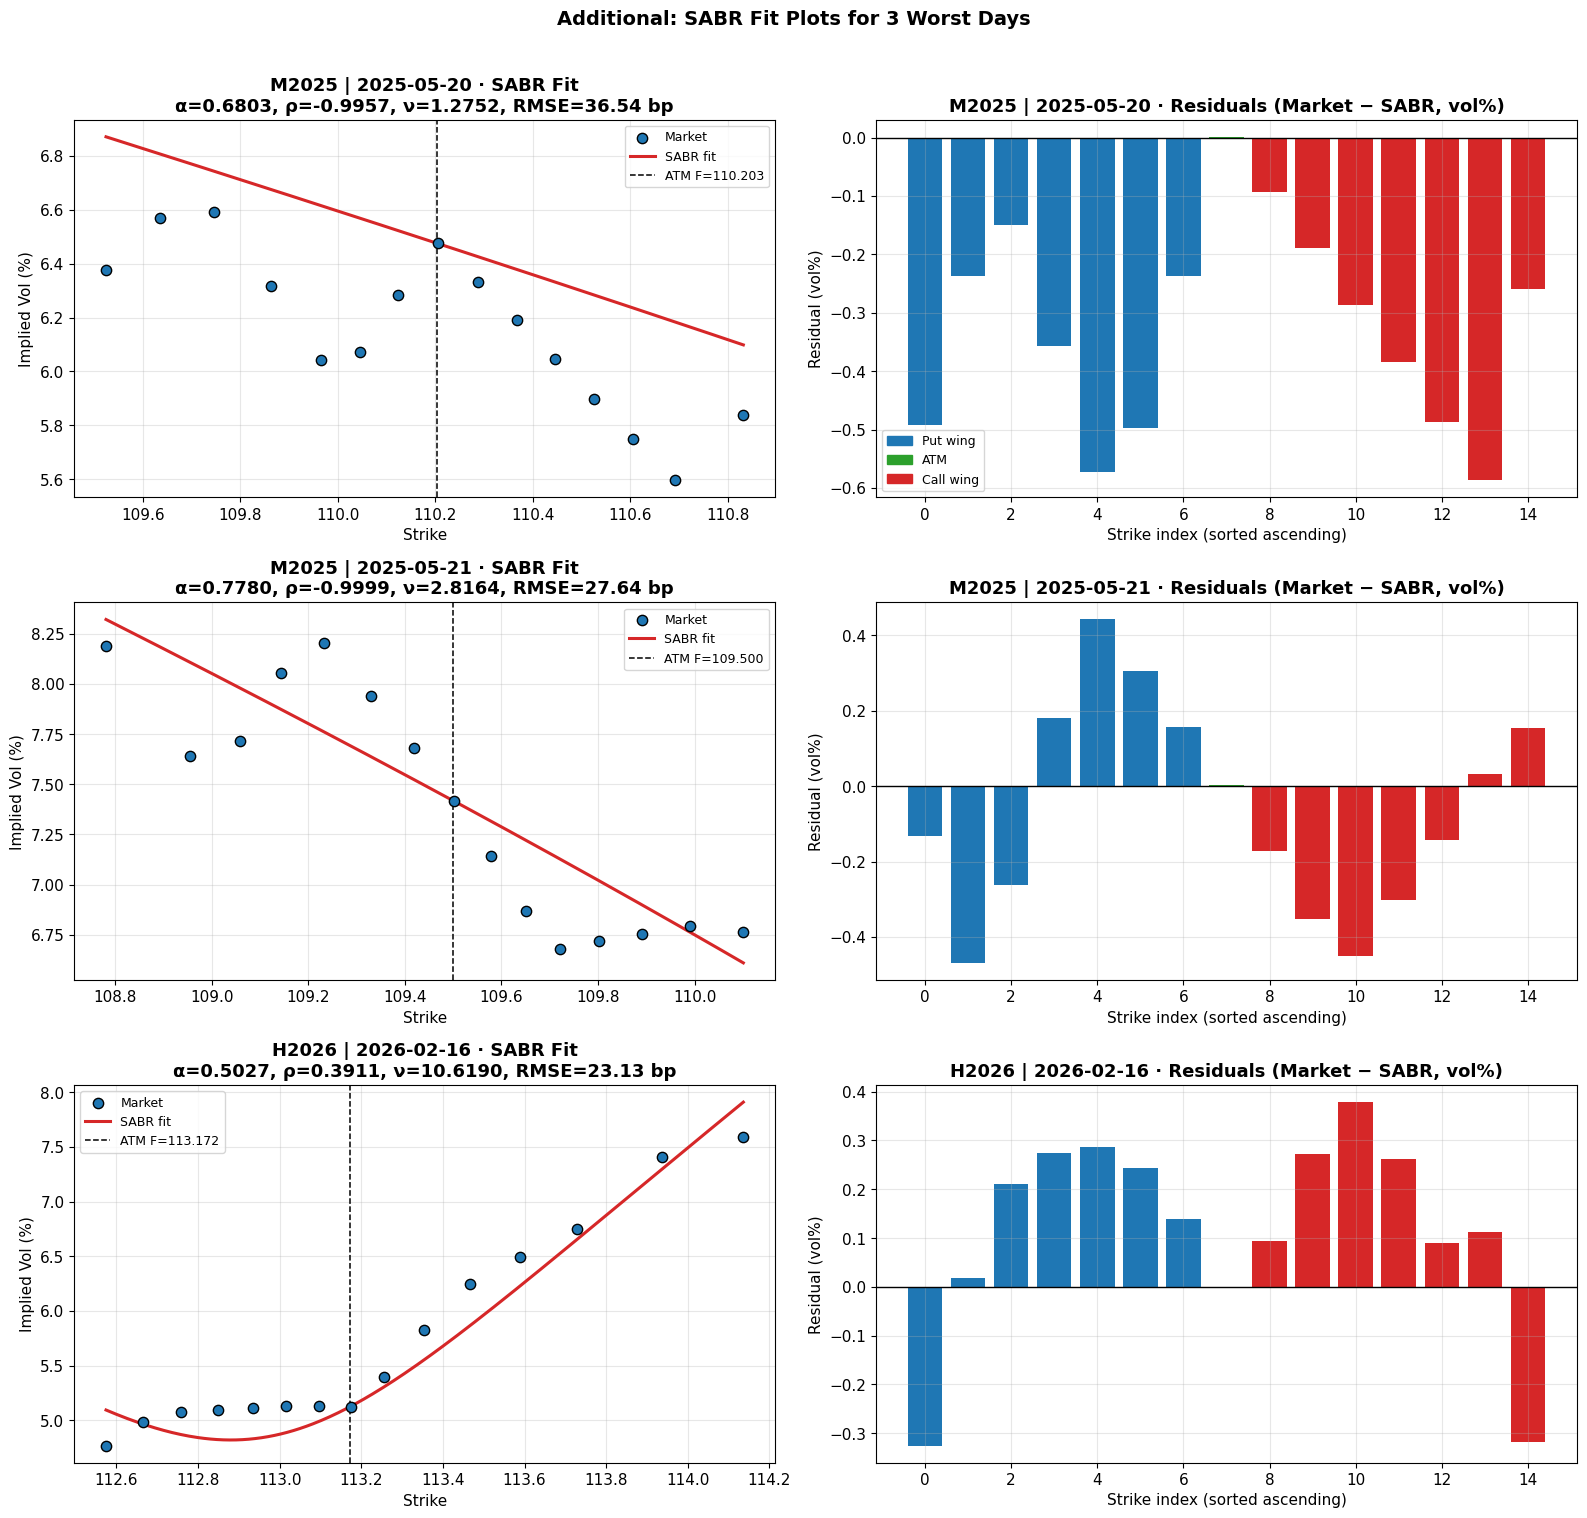

In [11]:
# 1) Identify worst 3 calibration dates from existing daily results
worst3 = (
    sabr_all.nlargest(3, "rmse")[["date", "contract", "rmse", "sigma_atm", "F", "T"]]
    .sort_values("rmse", ascending=False)
    .reset_index(drop=True)
)

display(
    worst3.assign(
        rmse_bp=lambda d: d["rmse"] * 10_000,
        sigma_atm_pct=lambda d: d["sigma_atm"] * 100
    )[["date", "contract", "sigma_atm_pct", "rmse_bp", "F", "T"]]
    .style.set_caption("Additional · Top 3 Worst Calibration Days")
)

# 2) Contract -> source surface map (already used elsewhere in notebook)
CONTRACT_DF = {
    "M2025": ty_option_surfaces_M2025,
    "H2026": ty_option_surfaces_H2026,
    "M2026": ty_option_surfaces_M2026,
}

# Helper to robustly fetch row by date
def _get_row_for_date(df_contract: pd.DataFrame, dt: pd.Timestamp) -> pd.Series:
    m = df_contract[df_contract["date"] == dt]
    if len(m) > 0:
        return m.iloc[0]
    # fallback: nearest date if exact timestamp mismatch
    nearest_idx = (df_contract["date"] - dt).abs().idxmin()
    return df_contract.loc[nearest_idx]

# 3) Build 3x2 panel: [fit | residual] x 3 worst days
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
_side_color_map = {"P": "#1f77b4", "C": "#d62728", "ATM": "#2ca02c", "?": "#888888"}

for i, ev in worst3.iterrows():
    dt = ev["date"]
    contract = ev["contract"]
    df_c = CONTRACT_DF[contract].sort_values("date").reset_index(drop=True)
    row = _get_row_for_date(df_c, dt)

    smile = build_smile(row)
    calib = calibrate_sabr(smile, beta=BETA)

    # If calibration failed for any reason, annotate and continue
    if not calib.get("success", False) or not np.isfinite(calib.get("rmse", np.nan)):
        axes[i, 0].text(0.5, 0.5, "Calibration failed", ha="center", va="center", transform=axes[i, 0].transAxes)
        axes[i, 1].text(0.5, 0.5, "Calibration failed", ha="center", va="center", transform=axes[i, 1].transAxes)
        continue

    F = float(row["Future Price"])
    T = float(row["Expiration Option"])

    # Smooth SABR curve
    K_min, K_max = float(np.nanmin(calib["strikes"])), float(np.nanmax(calib["strikes"]))
    K_grid = np.linspace(K_min, K_max, 300)
    sigma_grid = np.array([
        sabr_implied_vol(F, k, T, calib["alpha"], BETA, calib["rho"], calib["nu"])
        for k in K_grid
    ])

    # ---- Left: fit plot ----
    ax_fit = axes[i, 0]
    ax_fit.scatter(
        calib["strikes"], calib["vols"] * 100,
        s=55, color="#1f77b4", edgecolors="black", zorder=3, label="Market"
    )
    ax_fit.plot(K_grid, sigma_grid * 100, "-", color="#d62728", lw=2.2, label="SABR fit")
    ax_fit.axvline(F, color="black", ls="--", lw=1.1, label=f"ATM F={F:.3f}")
    ax_fit.set_title(
        f"{contract} | {pd.Timestamp(dt).date()} · SABR Fit\n"
        f"α={calib['alpha']:.4f}, ρ={calib['rho']:.4f}, ν={calib['nu']:.4f}, RMSE={calib['rmse']*10000:.2f} bp"
    )
    ax_fit.set_xlabel("Strike")
    ax_fit.set_ylabel("Implied Vol (%)")
    ax_fit.legend(loc="best", fontsize=9)

    # ---- Right: residual bar plot ----
    ax_res = axes[i, 1]
    resid = (calib["vols"] - calib["fitted"]) * 100  # vol%
    sides = calib.get("sides", np.array(["?"] * len(resid)))
    bar_colors = [_side_color_map.get(s, "#888888") for s in sides]
    ax_res.bar(np.arange(len(resid)), resid, color=bar_colors)
    ax_res.axhline(0, color="black", lw=1)
    ax_res.set_title(f"{contract} | {pd.Timestamp(dt).date()} · Residuals (Market − SABR, vol%)")
    ax_res.set_xlabel("Strike index (sorted ascending)")
    ax_res.set_ylabel("Residual (vol%)")

# Legend for side colors (shown once, top-right panel)
from matplotlib.patches import Patch
legend_patches = [
    Patch(color="#1f77b4", label="Put wing"),
    Patch(color="#2ca02c", label="ATM"),
    Patch(color="#d62728", label="Call wing"),
]
axes[0, 1].legend(handles=legend_patches, fontsize=9, loc="best")

fig.suptitle("Additional: SABR Fit Plots for 3 Worst Days", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## Question 3 – Calibration Quality and Regime Identification

### Q3 a) – Daily RMSE vs. ATM Volatility

If SABR systematically fails during volatile periods, we expect positive correlation
between ATM vol and RMSE. We test this with Pearson correlation and visual overlay.

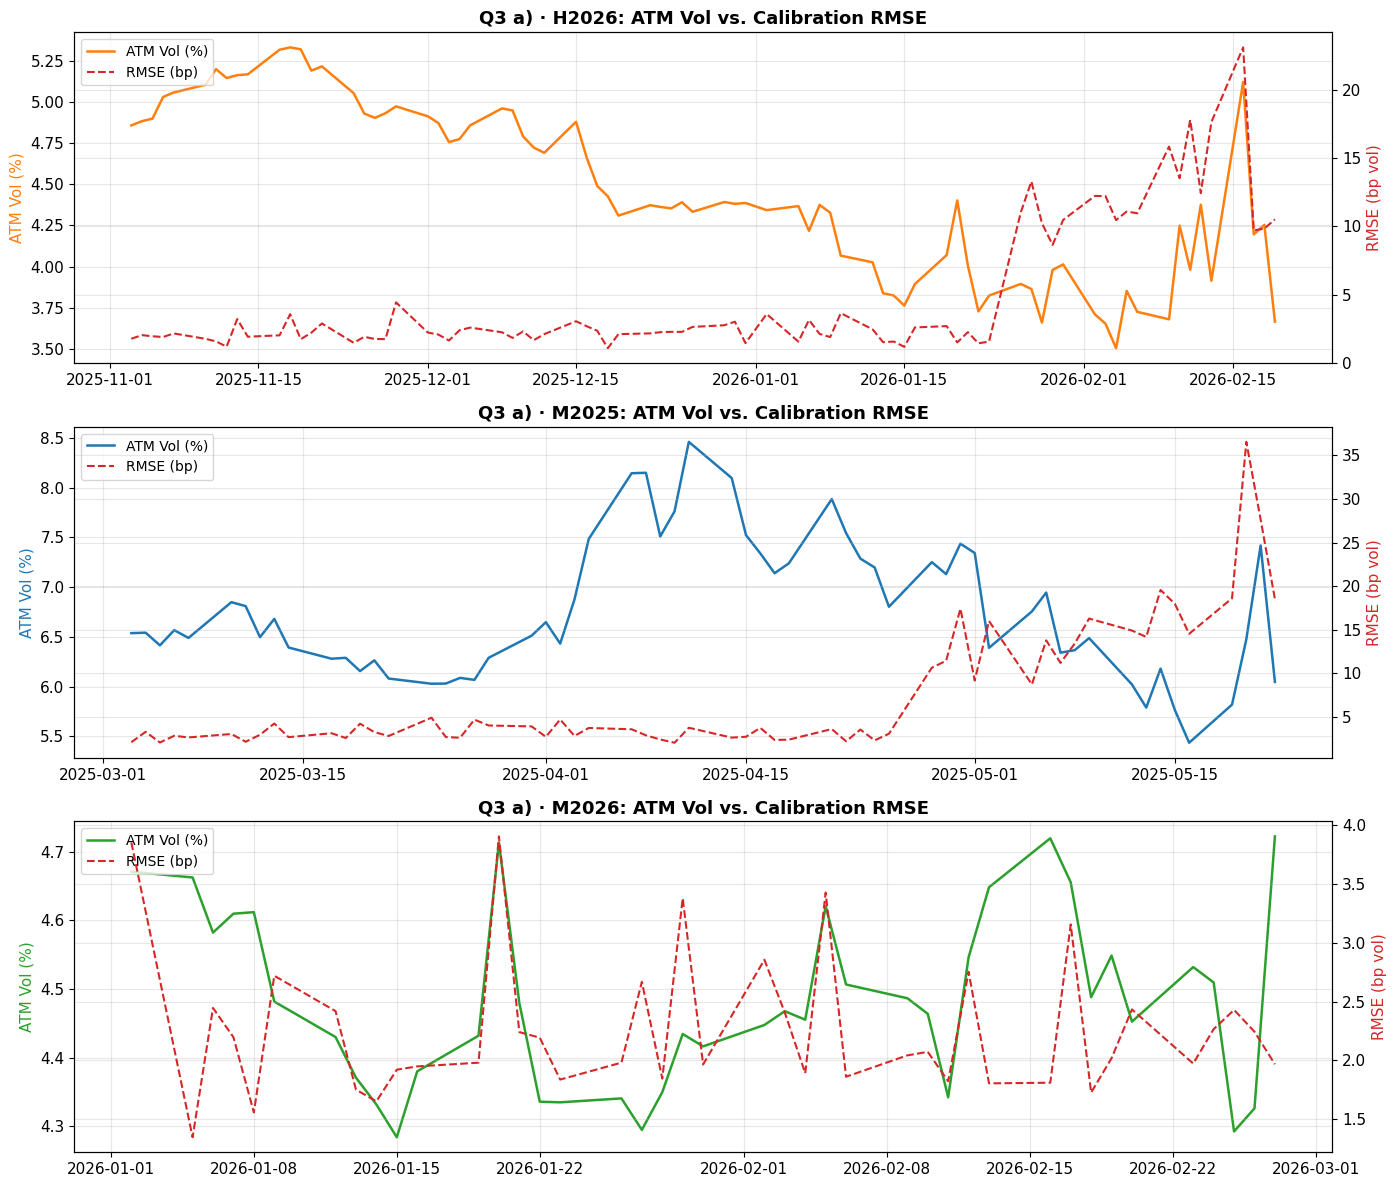

,Pearson r,p-value,N obs
Contract,,,
H2026,-0.440800,0.0001,78
M2025,-0.261200,0.0457,59
M2026,0.266300,0.0923,41


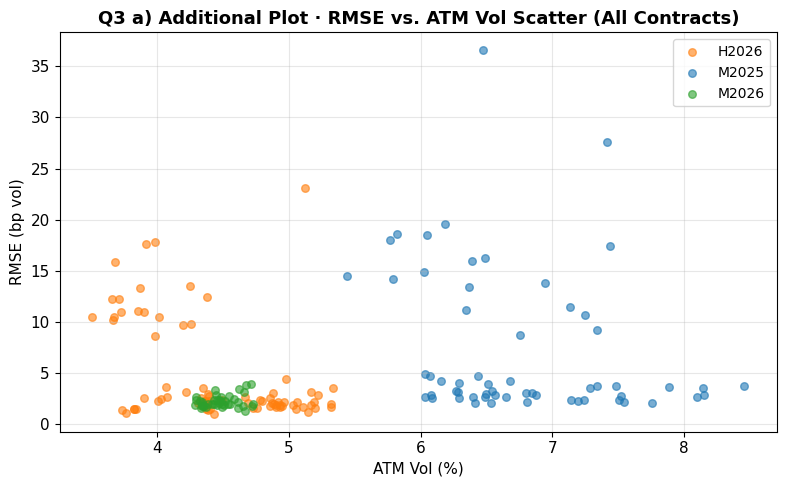

In [12]:
fig, axes = plt.subplots(len(CMAP), 1, figsize=(14, 12), sharex=False)
corr_records = []

for ax, (contract, grp) in zip(axes, sabr_all.groupby("contract")):
    grp = grp.sort_values("date")
    ax2 = ax.twinx()
    l1, = ax.plot(grp["date"], grp["sigma_atm"] * 100,
                  color=CMAP[contract], lw=1.8, label="ATM Vol (%)")
    l2, = ax2.plot(grp["date"], grp["rmse"] * 10_000,
                   color="#d62728", lw=1.5, ls="--", label="RMSE (bp)")
    ax.set_ylabel("ATM Vol (%)", color=CMAP[contract])
    ax2.set_ylabel("RMSE (bp vol)", color="#d62728")
    ax.set_title(f"Q3 a) · {contract}: ATM Vol vs. Calibration RMSE")
    ax.legend(handles=[l1, l2], loc="upper left")

    valid = grp[["sigma_atm", "rmse"]].dropna()
    r, p  = pearsonr(valid["sigma_atm"], valid["rmse"])
    corr_records.append({
        "Contract": contract,
        "Pearson r": round(r, 4),
        "p-value":   f"{p:.4f}",
        "N obs":     len(valid),
    })

fig.tight_layout()
plt.show()

display(pd.DataFrame(corr_records).set_index("Contract")
        .style.set_caption("Q3 a) · Pearson Correlation: ATM Vol vs. RMSE"))

# Additional Plot: Scatter plot — shows nonlinear relationship more clearly ───────────────
fig, ax = plt.subplots(figsize=(8, 5))
for contract, grp in sabr_all.groupby("contract"):
    ax.scatter(grp["sigma_atm"] * 100, grp["rmse"] * 10_000,
               color=CMAP[contract], alpha=0.6, s=30, label=contract)
ax.set_xlabel("ATM Vol (%)")
ax.set_ylabel("RMSE (bp vol)")
ax.set_title("Q3 a) Additional Plot · RMSE vs. ATM Vol Scatter (All Contracts)")
ax.legend()
fig.tight_layout()
plt.show()

#### Is there a systematic relationship between market volatility and calibration quality?

**Not in the “high volatility ⇒ worse fit” sense.** In our sample, the ATM-vol vs. RMSE relationship is contract-dependent and is *negative* for the two longer histories:

- **H2026:** Pearson r = **−0.4408** (p = **0.0001**, N = 78)  
- **M2025:** Pearson r = **−0.2612** (p = **0.0457**, N = 59)  
- **M2026:** Pearson r = **+0.2663** (p = 0.0923, N = 41; not statistically significant)

So, for H2026 and M2025, **higher ATM vol is associated with lower RMSE** (better fit), while M2026 is inconclusive. Overall, calibration quality is driven more by **smile geometry / maturity effects** (e.g., near-expiry instability and extreme fitted parameters) than by the *level* of market volatility alone.

### Q3 b) – Largest Day-over-Day SABR Parameter Shifts

Metric: $|Δ\nu| + |Δ\rho|$ computed contract-by-contract.
Top 5 dates globally; pre/post smiles shown for the three largest events.

,date,contract,alpha,rho,nu,d_nu,d_rho,change_score,sigma_atm_pct,rmse_bp
0,2025-05-20 00:00:00,M2025,0.680265,-0.995674,1.275231,-7.037931,-0.778946,7.816877,6.475750,36.539183
1,2026-02-19 00:00:00,H2026,0.390385,0.948208,4.568368,-6.841723,0.867068,7.708791,3.665800,10.510868
2,2025-05-19 00:00:00,M2025,0.575338,-0.216729,8.313163,6.702943,0.062449,6.765392,5.819850,18.611681
3,2026-02-13 00:00:00,H2026,0.384294,0.391473,8.109780,6.313894,-0.402415,6.716309,3.914600,17.647875
4,2025-05-22 00:00:00,M2025,0.639589,-0.997662,8.065507,5.249119,0.002195,5.251314,6.047700,18.515988


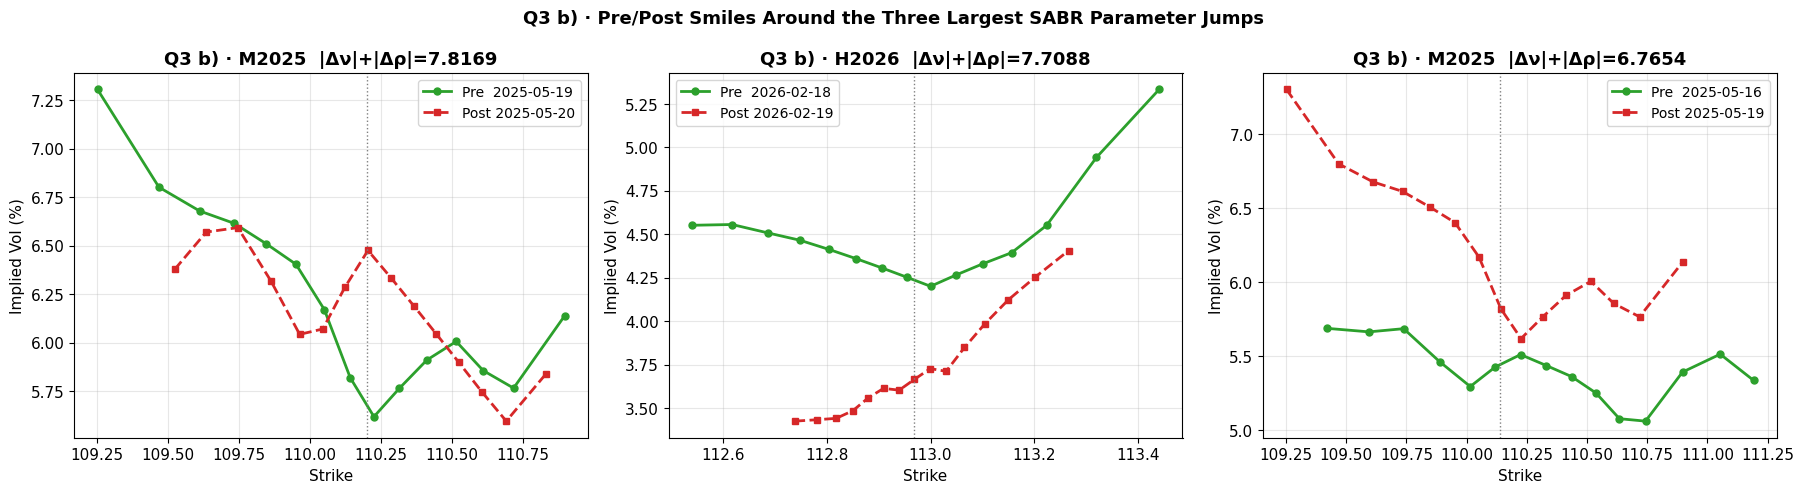

In [13]:
sabr_all = sabr_all.sort_values(["contract", "date"]).copy()
sabr_all["d_nu"]        = sabr_all.groupby("contract")["nu"].diff()
sabr_all["d_rho"]       = sabr_all.groupby("contract")["rho"].diff()
sabr_all["change_score"] = sabr_all["d_nu"].abs() + sabr_all["d_rho"].abs()

top5 = (sabr_all.dropna(subset=["change_score"])
        .nlargest(5, "change_score")
        [["date", "contract", "sigma_atm", "alpha", "rho", "nu",
          "d_nu", "d_rho", "change_score", "rmse"]]
        .reset_index(drop=True))

display(
    top5.assign(sigma_atm_pct=lambda d: d["sigma_atm"] * 100,
                rmse_bp=lambda d: d["rmse"] * 10_000)
    .drop(columns=["sigma_atm", "rmse"])
    .style.set_caption(
        "Q3 b) · Top 5 Dates by Largest Day-over-Day SABR Parameter Change (|Δν| + |Δρ|)"
    )
)

# Pre/post smile plots for top 3 events
CONTRACT_DF = {
    "M2025": ty_option_surfaces_M2025,
    "H2026": ty_option_surfaces_H2026,
    "M2026": ty_option_surfaces_M2026,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (_, ev) in enumerate(top5.head(3).iterrows()):
    contract = ev["contract"]
    dt       = ev["date"]
    df_c     = CONTRACT_DF[contract].sort_values("date").reset_index(drop=True)
    pos      = df_c.index[df_c["date"] == dt].tolist()
    ax       = axes[idx]
    if not pos or pos[0] == 0:
        ax.text(0.5, 0.5, "No pre-date available",
                ha="center", va="center", transform=ax.transAxes)
        continue

    pre_row    = df_c.iloc[pos[0] - 1]
    post_row   = df_c.iloc[pos[0]]
    pre_smile  = build_smile(pre_row)
    post_smile = build_smile(post_row)

    ax.plot(pre_smile["strike"],  pre_smile["vol"] * 100,  "o-",
            color="#2ca02c", lw=2, ms=5, label=f"Pre  {pre_row['date'].date()}")
    ax.plot(post_smile["strike"], post_smile["vol"] * 100, "s--",
            color="#d62728", lw=2, ms=5, label=f"Post {post_row['date'].date()}")
    ax.axvline(float(post_row["Future Price"]), color="grey", ls=":", lw=1)
    ax.set_title(f"Q3 b) · {contract}  |Δν|+|Δρ|={ev['change_score']:.4f}")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Implied Vol (%)")
    ax.legend()

fig.suptitle("Q3 b) · Pre/Post Smiles Around the Three Largest SABR Parameter Jumps",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

The largest day-over-day SABR parameter moves are driven mainly by **near-expiry smile instability**, not by “level of vol” per se.

- **Where the jumps occur.** The top-5 events by $(|Δ\nu|+|Δ\rho|$) concentrate in the **final days of each contract**:  
  - **M2025:** 2025‑05‑19, **05‑20**, 05‑22 (M2025 ends 2025‑05‑22)  
  - **H2026:** 2026‑02‑13, **02‑19** (H2026 ends 2026‑02‑19)

- **What changes mechanically.** These days feature **extreme / boundary-like fits** with an ill-conditioned calibration as $(T \to 0$):  
  - **2025‑05‑20 (M2025):** $(Δ\nu=-7.04$), $(Δ\rho=-0.78$), $(\rho\approx-0.996$), RMSE **36.54 bp**  
  - **2026‑02‑19 (H2026):** $(Δ\nu=-6.84$), $(Δ\rho=+0.87$), RMSE **10.51 bp**  
  - Other top days show **ν spikes** (e.g., M2025 $(\nu=8.31$) on 05‑19; H2026 $(\nu=8.11$) on 02‑13) and large $(Δ\nu$) with smaller $(Δ\rho$).

- **Economic interpretation.** The pre/post smile overlays show the **wings re-shaping sharply** over a single day; near expiry, small quote changes in the wings can imply very different curvature/skew, so the optimizer “uses” **ν and ρ** to absorb that geometry. Practically, these jumps are best read as a **near-expiry / microstructure + SABR-approximation sensitivity** effect (and are the same window where RMSE outliers cluster), rather than cleanly attributable macro news.

### Q3 c) – Term-Structure of SABR Parameters: H2026 vs. M2026

Both contracts are quoted during January–February 2026 but expire at different times
(H2026 in Feb 2026, M2026 in May 2026). Comparing same-calendar-day SABR parameters
isolates the effect of **time-to-expiry** on smile shape.

,Overlap Start,Overlap End,Num Days
0,2026-01-02,2026-02-19,35


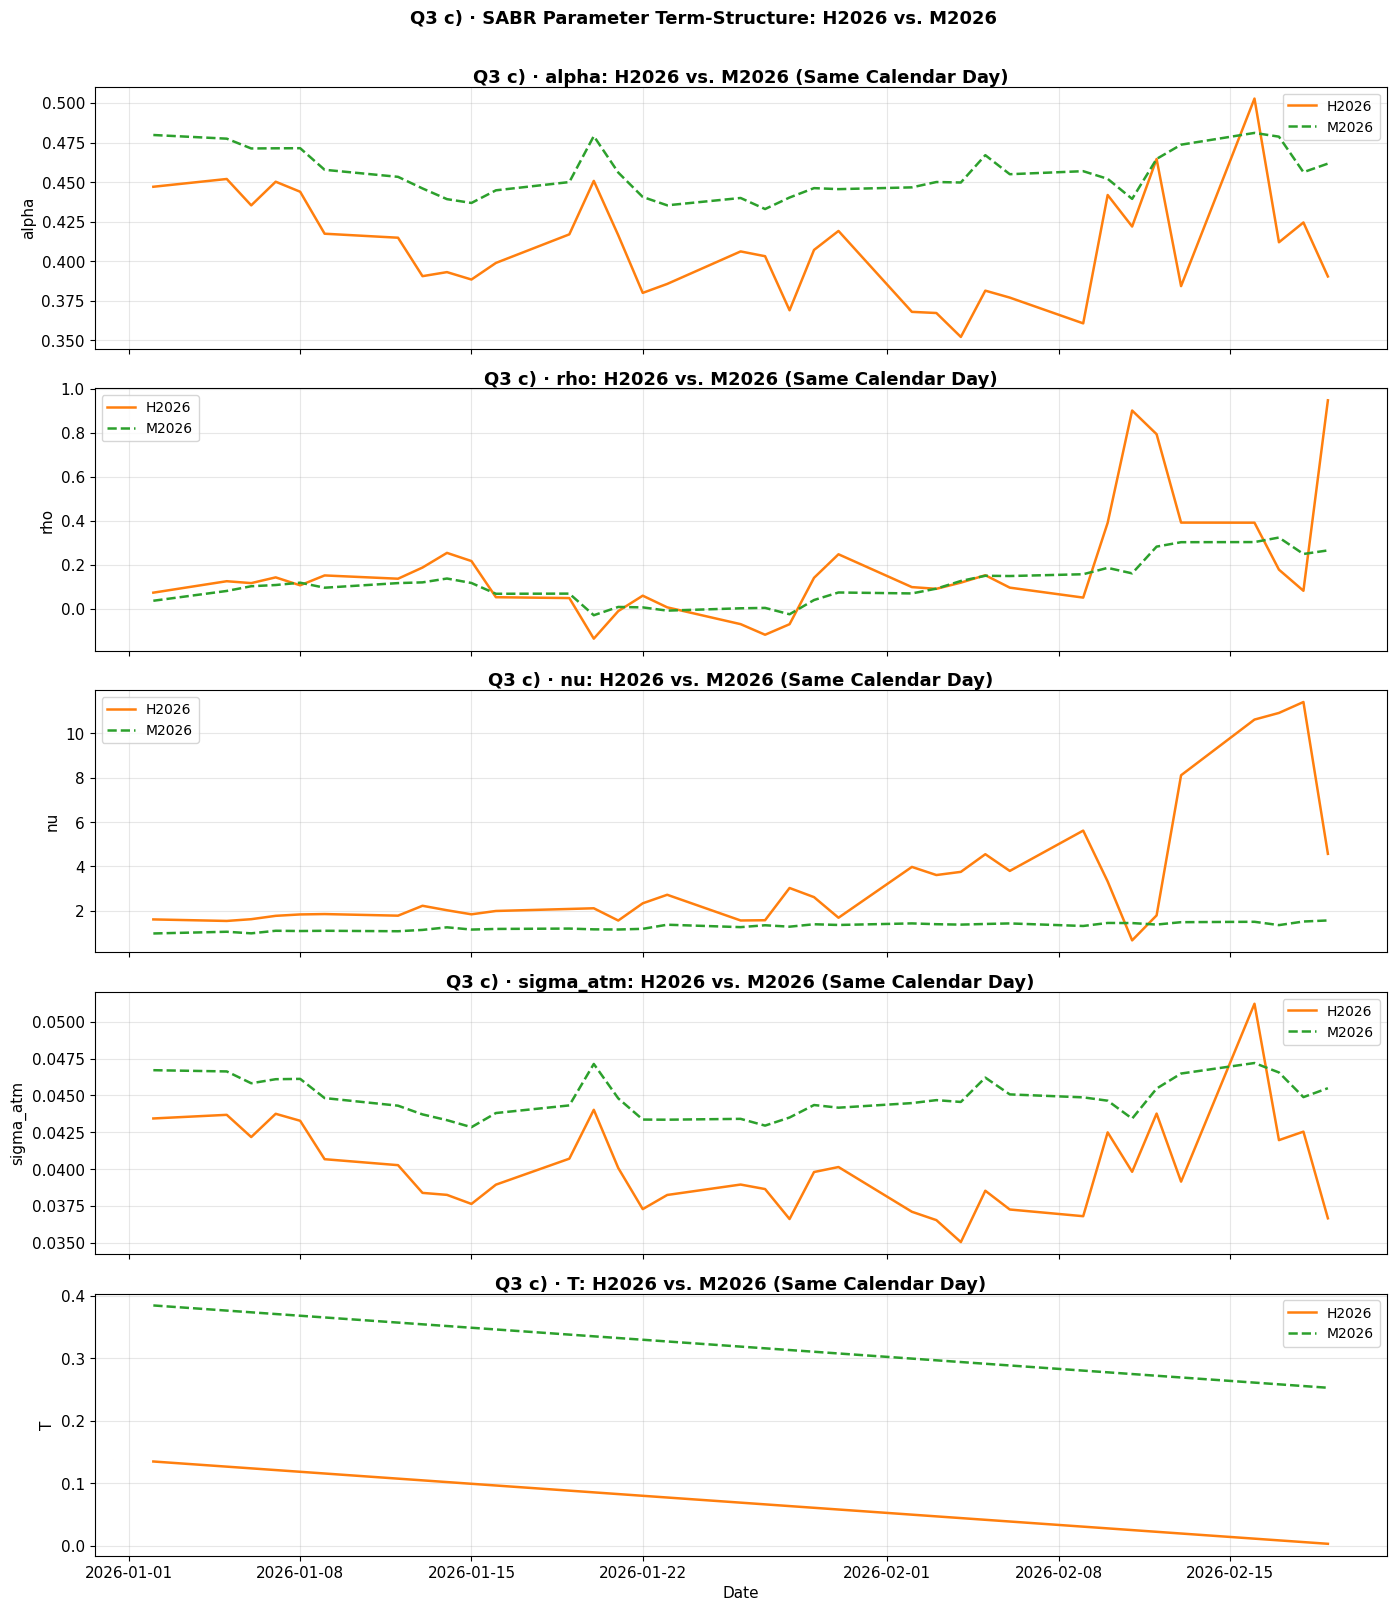

,Mean H2026,Mean M2026,Mean Diff (H–M)
Parameter,,,
α,0.409578,0.455646,-0.046069
ρ,0.180734,0.115320,0.065414
ν,3.376316,1.285605,2.090710
σ_ATM,0.040108,0.044842,-0.004734
T (yrs),0.067425,0.316740,-0.249315


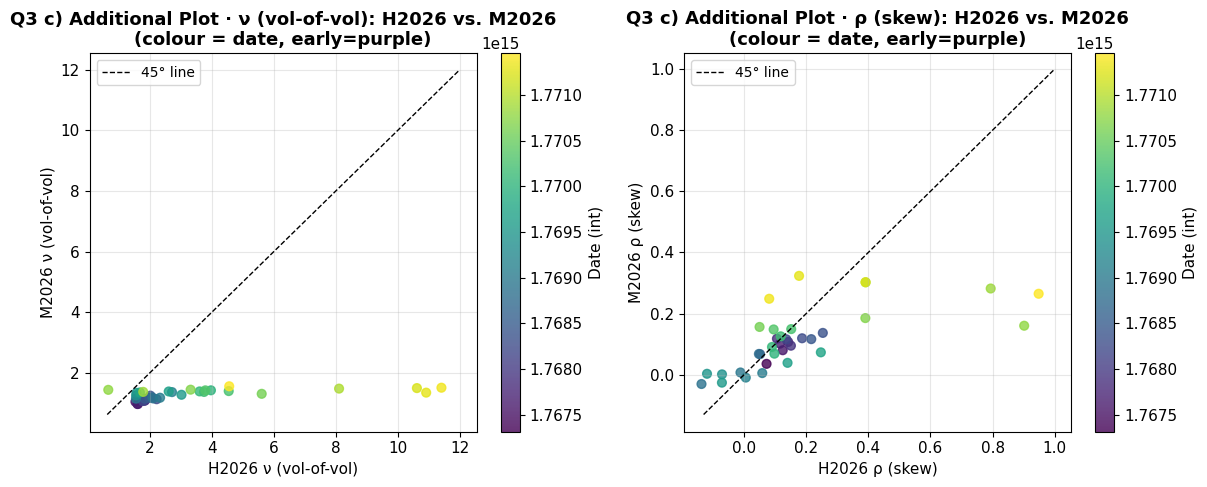

In [14]:
overlap = (sabr_H2026.merge(sabr_M2026, on="date", suffixes=("_H2026", "_M2026"))
           .sort_values("date"))

display(pd.DataFrame({
    "Overlap Start": [overlap["date"].min().date()],
    "Overlap End":   [overlap["date"].max().date()],
    "Num Days":      [len(overlap)],
}).style.set_caption("Q3 c) · Overlap Window: H2026 vs. M2026"))

# Time-series comparison of key SABR parameters
params_ov = ["alpha", "rho", "nu", "sigma_atm", "T"]
fig, axes  = plt.subplots(len(params_ov), 1, figsize=(14, 16), sharex=True)

for ax, p in zip(axes, params_ov):
    ax.plot(overlap["date"], overlap[f"{p}_H2026"],
            color="#ff7f0e", lw=1.8, label=f"H2026")
    ax.plot(overlap["date"], overlap[f"{p}_M2026"],
            color="#2ca02c", lw=1.8, ls="--", label=f"M2026")
    ax.set_ylabel(p)
    ax.legend()
    ax.set_title(f"Q3 c) · {p}: H2026 vs. M2026 (Same Calendar Day)", pad=3)

axes[-1].set_xlabel("Date")
fig.suptitle("Q3 c) · SABR Parameter Term-Structure: H2026 vs. M2026",
             fontsize=13, fontweight="bold", y=1.005)
fig.tight_layout()
plt.show()

# Summary statistics of differences
diff_stats = pd.DataFrame({
    "Parameter":       ["α", "ρ", "ν", "σ_ATM", "T (yrs)"],
    "Mean H2026":      [overlap[f"{p}_H2026"].mean()
                        for p in ["alpha","rho","nu","sigma_atm","T"]],
    "Mean M2026":      [overlap[f"{p}_M2026"].mean()
                        for p in ["alpha","rho","nu","sigma_atm","T"]],
    "Mean Diff (H–M)": [(overlap[f"{p}_H2026"] - overlap[f"{p}_M2026"]).mean()
                        for p in ["alpha","rho","nu","sigma_atm","T"]],
}).round(6)
display(diff_stats.set_index("Parameter")
        .style.set_caption("Q3 c) · Average SABR Parameters: H2026 vs. M2026 Overlap"))

# Additional Plot: Scatter of ν_H2026 vs ν_M2026 to show term-structure relationship ─────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, param, ylabel in [
    (axes[0], "nu",  "ν (vol-of-vol)"),
    (axes[1], "rho", "ρ (skew)"),
]:
    sc = ax.scatter(overlap[f"{param}_H2026"], overlap[f"{param}_M2026"],
                    c=pd.to_datetime(overlap["date"]).astype("int64"),
                    cmap="viridis", s=40, alpha=0.8)
    lim_lo = min(overlap[f"{param}_H2026"].min(), overlap[f"{param}_M2026"].min()) * 0.95
    lim_hi = max(overlap[f"{param}_H2026"].max(), overlap[f"{param}_M2026"].max()) * 1.05
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=1, label="45° line")
    ax.set_xlabel(f"H2026 {ylabel}")
    ax.set_ylabel(f"M2026 {ylabel}")
    ax.set_title(f"Q3 c) Additional Plot · {ylabel}: H2026 vs. M2026\n(colour = date, early=purple)")
    ax.legend()
    plt.colorbar(sc, ax=ax, label="Date (int)")
fig.tight_layout()
plt.show()

Yes — **smile shape depends strongly on time-to-expiry**, even on the *same calendar dates*.

In the 35‑day overlap window (2026‑01‑02 to 2026‑02‑19), the nearer-expiry **H2026** and longer-expiry **M2026** show materially different *shape* parameters:

- **Curvature (ν):** H2026 mean **3.376** vs M2026 mean **1.286** (Δ = **+2.091**).  
  The shorter-dated contract embeds **much more curvature / vol-of-vol**, i.e., a “fatter-wing” smile.
- **Skew (ρ):** H2026 mean **0.181** vs M2026 mean **0.115** (Δ = **+0.065**).  
  The near-expiry smile is also **more skewed** (stronger price/vol correlation in this sample).
- **Level (σ_ATM) moves the other way:** H2026 σ_ATM **4.01%** vs M2026 **4.48%** (Δ = **−0.47%**).  

So the **level term structure** (ATM) and the **shape term structure** (ν, ρ) are distinct: the near-expiry option can have *lower* ATM vol but a *more curved* (higher‑ν) smile. This is why parameters must be calibrated by tenor, not pooled across expiries.

### Q3 d) – Lazy Recalibration: Stale (ν, ρ), Updated α Only

We test holding $(ν, ρ)$ fixed at their values from $N = 5, 10, 20$ days ago, updating
only $α$ each day through the ATM constraint. The RMSE uplift vs. daily full recalibration
measures how quickly stale parameters degrade fit quality.

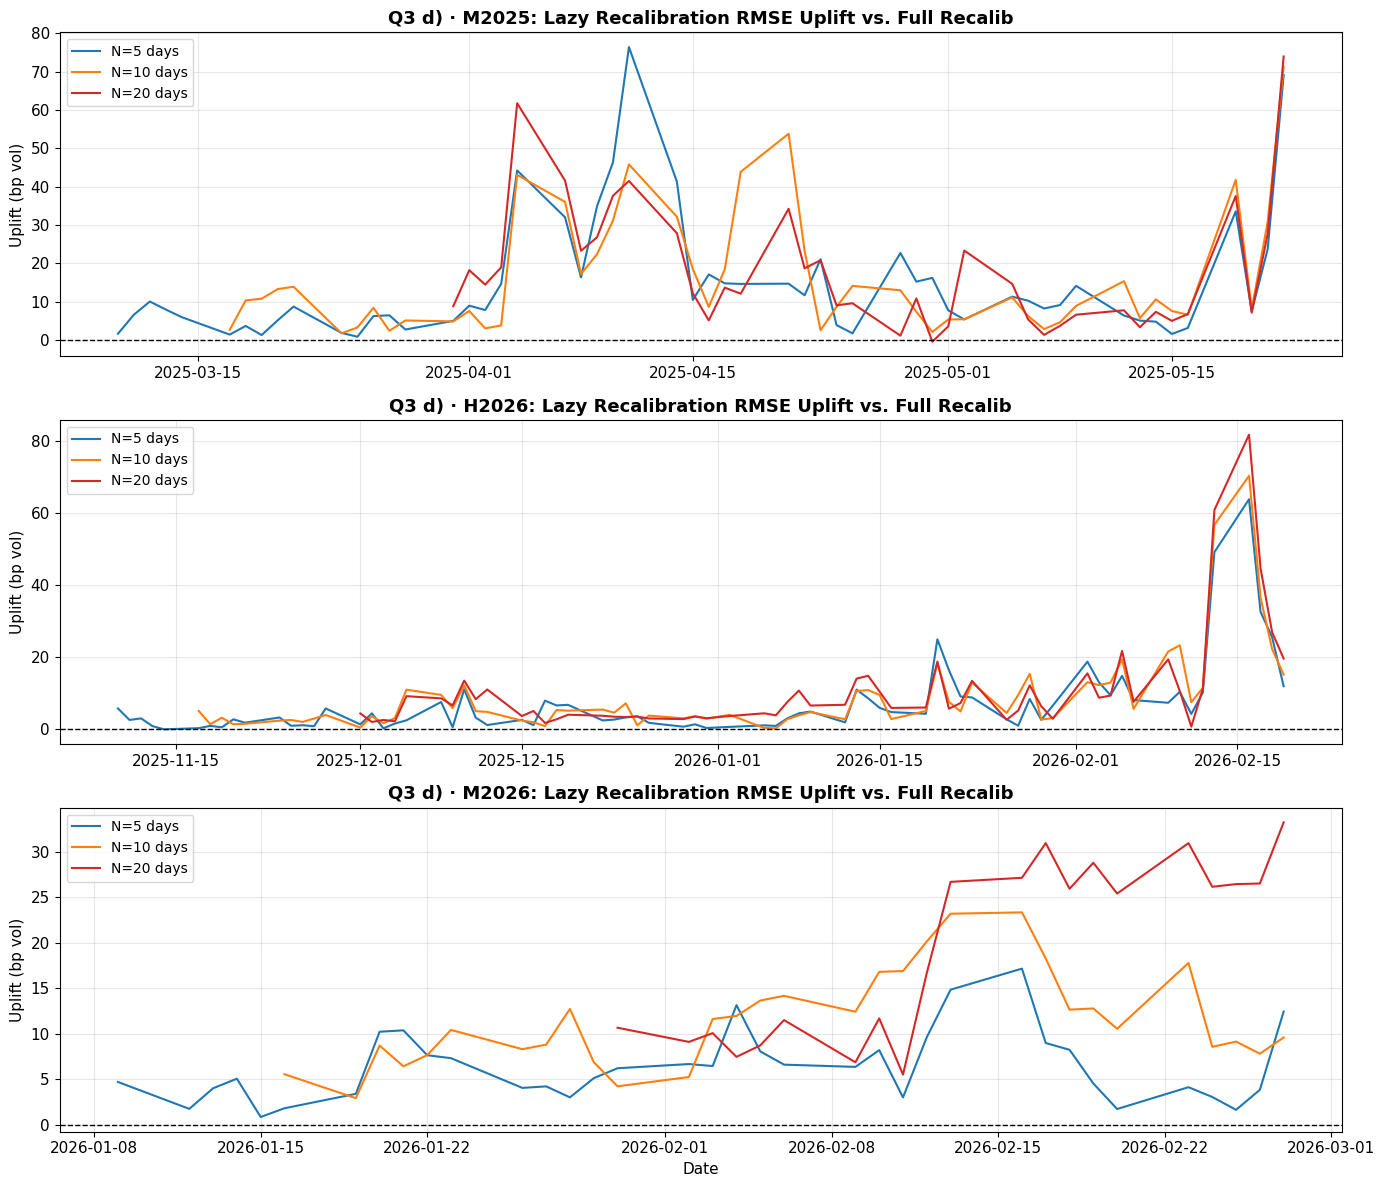

In [15]:
def lazy_rmse(df_surface: pd.DataFrame, sabr_calib_df: pd.DataFrame,
              stale_days: int, beta: float = BETA) -> pd.DataFrame:
    """
    Lazy recalibration RMSE: use (ν, ρ) from `stale_days` ago,
    update α via the ATM constraint each day.
    """
    df_s  = df_surface.sort_values("date").reset_index(drop=True)
    cal_s = sabr_calib_df.sort_values("date").reset_index(drop=True)
    records = []

    for i in range(stale_days, len(df_s)):
        stale_row = cal_s.iloc[i - stale_days]
        nu_stale  = float(stale_row["nu"])
        rho_stale = float(stale_row["rho"])
        if not (np.isfinite(nu_stale) and np.isfinite(rho_stale)):
            continue

        row    = df_s.iloc[i]
        smile  = build_smile(row)
        sub    = smile.dropna(subset=["strike", "vol"])
        sub    = sub[(sub["strike"] > 0) & (sub["vol"] > 0)]
        if len(sub) < 4:
            continue

        strikes   = sub["strike"].to_numpy(dtype=float)
        mkt_vols  = sub["vol"].to_numpy(dtype=float)
        F         = float(row["Future Price"])
        T         = float(row["Expiration Option"])
        sigma_atm = float(np.interp(F, strikes, mkt_vols))

        alpha_lazy = solve_alpha(sigma_atm, F, T, beta, rho_stale, nu_stale)
        if not np.isfinite(alpha_lazy):
            continue

        fitted_lazy = np.array([
            sabr_implied_vol(F, k, T, alpha_lazy, beta, rho_stale, nu_stale)
            for k in strikes
        ])
        rmse_lazy = float(np.sqrt(np.mean((fitted_lazy - mkt_vols)**2)))
        records.append({
            "date":       row["date"],
            "contract":   row.get("contract", ""),
            "stale_days": stale_days,
            "rmse_lazy":  rmse_lazy,
        })
    return pd.DataFrame(records)


# Run for all contracts and stale horizons
lazy_records = []
for N in [5, 10, 20]:
    for df_s, cal_s in [(ty_option_surfaces_M2025, sabr_M2025),
                         (ty_option_surfaces_H2026, sabr_H2026),
                         (ty_option_surfaces_M2026, sabr_M2026)]:
        lazy_records.append(lazy_rmse(df_s, cal_s, N))

lazy_df = pd.concat(lazy_records, ignore_index=True)

# Merge with full-recalibration RMSE
lazy_merged = lazy_df.merge(
    sabr_all[["date", "contract", "rmse"]].rename(columns={"rmse": "rmse_full"}),
    on=["date", "contract"], how="left"
)
lazy_merged["rmse_uplift"] = lazy_merged["rmse_lazy"] - lazy_merged["rmse_full"]

# Summary table
lazy_summary = (lazy_merged.groupby(["contract", "stale_days"])
                [["rmse_full", "rmse_lazy", "rmse_uplift"]]
                .mean() * 10_000).round(3)
lazy_summary.columns = ["Full Recalib RMSE (bp)", "Lazy RMSE (bp)", "Uplift (bp)"]
display(lazy_summary.style.set_caption(
    "Q3 d) · Average RMSE: Full vs. Lazy Recalibration (bp vol)"))

# RMSE uplift time series
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
for ax, contract in zip(axes, ["M2025", "H2026", "M2026"]):
    sub = lazy_merged[lazy_merged["contract"] == contract]
    for N, col in zip([5, 10, 20], ["#1f77b4", "#ff7f0e", "#d62728"]):
        g = sub[sub["stale_days"] == N]
        ax.plot(g["date"], g["rmse_uplift"] * 10_000,
                color=col, lw=1.5, label=f"N={N} days")
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set_title(f"Q3 d) · {contract}: Lazy Recalibration RMSE Uplift vs. Full Recalib")
    ax.set_ylabel("Uplift (bp vol)")
    ax.legend()
axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()

Stale shape parameters degrade fit **quickly**. Holding $((\nu,\rho)$) fixed and only re-solving $(α$) to match ATM produces a **material RMSE penalty within 1 week** and it grows monotonically with staleness:

Average RMSE uplift vs full daily recalibration (bp vol):

- **H2026:** +7.04 (5d), +8.72 (10d), +10.66 (20d)  
- **M2025:** +14.49 (5d), +15.80 (10d), +18.00 (20d)  
- **M2026:** +6.36 (5d), +11.60 (10d), +19.36 (20d)

**Implication for recalibration frequency.** Weekly “lazy” updating is already costly (≈6–15 bp RMSE), and two–four week staleness can add ~11–19 bp. So **daily recalibration of $((\nu,\rho)$)** is justified operationally, with the strongest case in **M2025** (largest and fastest deterioration) and whenever the smile is changing rapidly.

### Extra Analysis: Fix Parameters from Day 1 and Track RMSE Evolution Over Time

As an extended experiment, we consider locking in all but alpha (α) of the SABR parameters
to its estimated value from the first measurement day.

This reveals the sensitivity of fit quality (RMSE) to stale parameterization over time.

,Contract,First Date,α day-1 (reference),β fixed,ρ fixed,ν fixed,σ_ATM day-1 (%),Full RMSE day-1 (bp)
0,M2025,2025-03-03,0.677681,0.50,0.247978,1.027732,6.5377,2.114
1,H2026,2025-11-03,0.499392,0.50,0.099788,1.143318,4.8581,1.755
2,M2026,2026-01-02,0.479741,0.50,0.035679,0.980688,4.6708,3.855


,Contract,Avg Full RMSE (bp),Avg Stale-Shape RMSE (bp),Avg Uplift (bp),Max Uplift (bp)
0,M2025,7.376,20.444,13.068,75.754
1,H2026,4.735,14.638,9.903,83.489
2,M2026,2.262,17.521,15.259,41.663


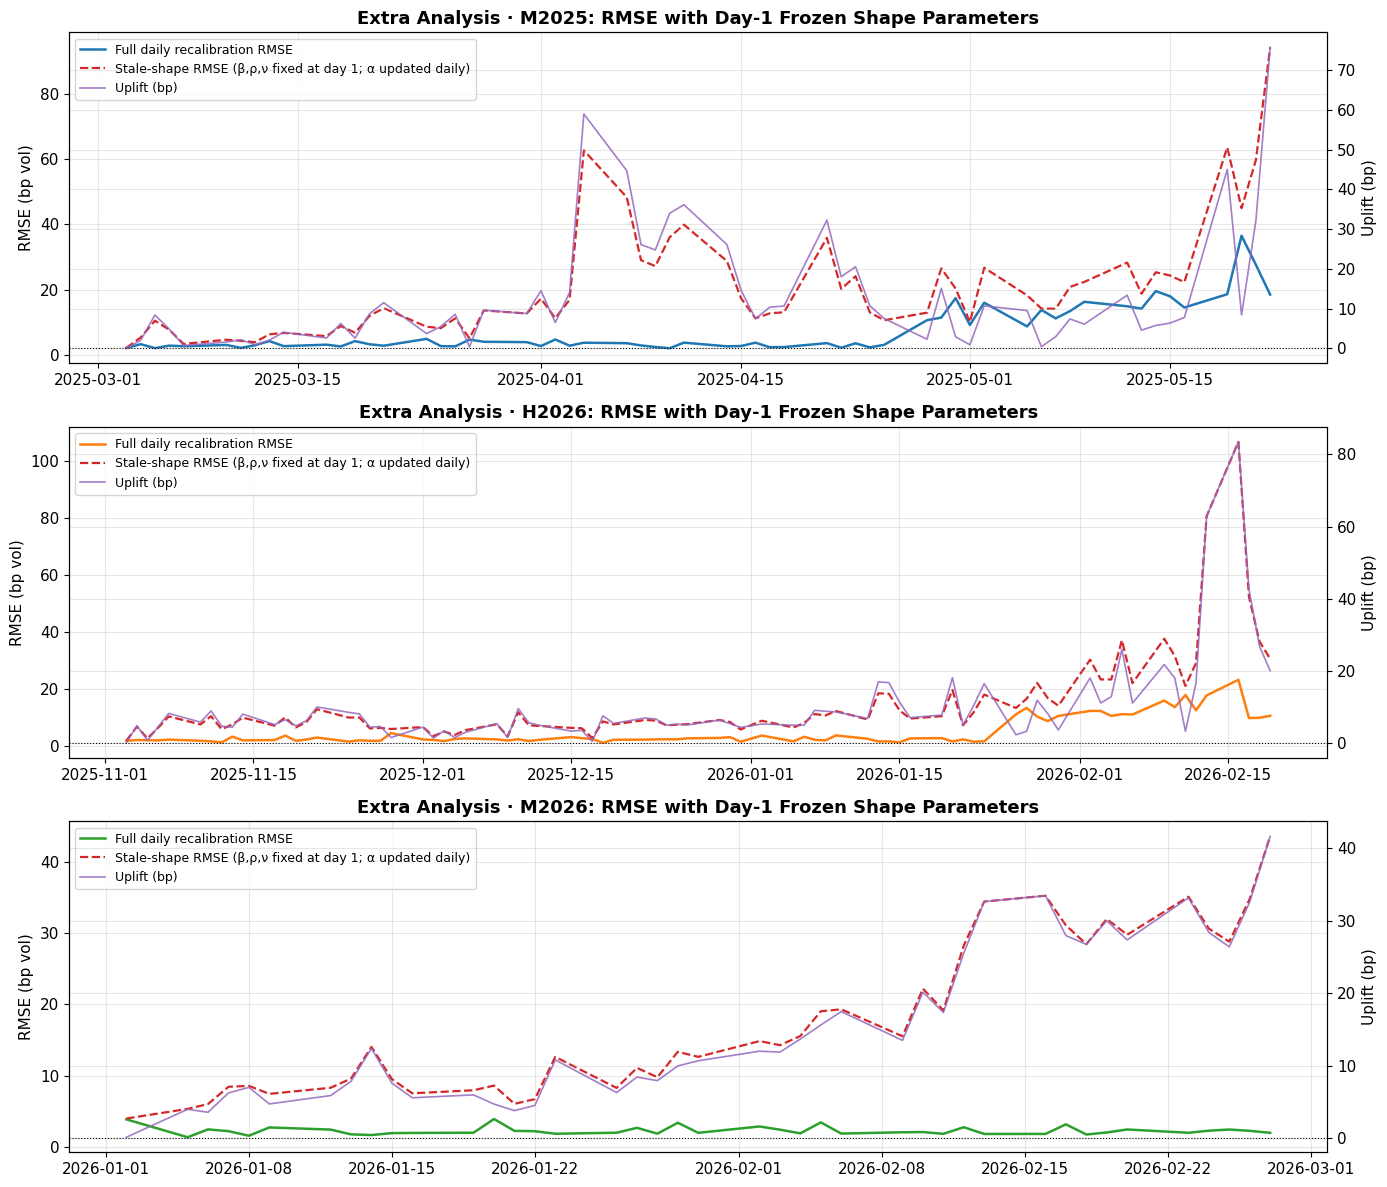

In [16]:
# Freeze (beta, rho, nu) at day 1, re-solve alpha daily from ATM
def rmse_with_day1_shape_daily_alpha(
    df_surface: pd.DataFrame,
    beta_fixed: float,
    rho_fixed: float,
    nu_fixed: float,
) -> pd.DataFrame:
    """
    Daily RMSE with stale shape params (rho, nu, beta fixed),
    while alpha is updated each day via ATM constraint.
    """
    records = []

    for _, row in df_surface.sort_values("date").iterrows():
        smile = build_smile(row)
        sub = smile.dropna(subset=["strike", "vol"]).copy()
        sub = sub[(sub["strike"] > 0) & (sub["vol"] > 0)]

        if len(sub) < 4:
            records.append(
                {"date": row["date"], "alpha_daily": np.nan, "rmse_stale_shape": np.nan}
            )
            continue

        F = float(row["Future Price"])
        T = float(row["Expiration Option"])
        strikes = sub["strike"].to_numpy(dtype=float)
        mkt_vols = sub["vol"].to_numpy(dtype=float)

        # Daily ATM vol from current smile
        sigma_atm = float(np.interp(F, strikes, mkt_vols))

        # Re-solve alpha each day with stale (beta, rho, nu)
        alpha_daily = solve_alpha(sigma_atm, F, T, beta_fixed, rho_fixed, nu_fixed)

        if not np.isfinite(alpha_daily) or alpha_daily <= 0:
            records.append(
                {"date": row["date"], "alpha_daily": np.nan, "rmse_stale_shape": np.nan}
            )
            continue

        fitted = np.array([
            sabr_implied_vol(F, k, T, alpha_daily, beta_fixed, rho_fixed, nu_fixed)
            for k in strikes
        ])

        rmse = (
            np.nan
            if not np.all(np.isfinite(fitted))
            else float(np.sqrt(np.mean((mkt_vols - fitted) ** 2)))
        )

        records.append(
            {"date": row["date"], "alpha_daily": alpha_daily, "rmse_stale_shape": rmse}
        )

    return pd.DataFrame(records).sort_values("date").reset_index(drop=True)


# Inputs and daily full-calibration outputs already built earlier in notebook
CONTRACT_INPUT = {
    "M2025": ty_option_surfaces_M2025,
    "H2026": ty_option_surfaces_H2026,
    "M2026": ty_option_surfaces_M2026,
}
CONTRACT_CALIB = {
    "M2025": sabr_M2025.sort_values("date").reset_index(drop=True),
    "H2026": sabr_H2026.sort_values("date").reset_index(drop=True),
    "M2026": sabr_M2026.sort_values("date").reset_index(drop=True),
}

stale_shape_results = {}
frozen_shape_rows = []

for contract in ["M2025", "H2026", "M2026"]:
    cal = CONTRACT_CALIB[contract]
    inp = CONTRACT_INPUT[contract].sort_values("date").reset_index(drop=True)

    first = cal.iloc[0]
    beta0 = float(first["beta"])
    rho0 = float(first["rho"])
    nu0 = float(first["nu"])
    alpha0 = float(first["alpha"])

    frozen_shape_rows.append(
        {
            "Contract": contract,
            "First Date": pd.Timestamp(first["date"]).date(),
            "α day-1 (reference)": alpha0,
            "β fixed": beta0,
            "ρ fixed": rho0,
            "ν fixed": nu0,
            "σ_ATM day-1 (%)": float(first["sigma_atm"]) * 100,
            "Full RMSE day-1 (bp)": float(first["rmse"]) * 10_000,
        }
    )

    stale = rmse_with_day1_shape_daily_alpha(inp, beta0, rho0, nu0)

    merged = cal[["date", "rmse", "alpha"]].merge(stale, on="date", how="left")
    merged["uplift_bp"] = (merged["rmse_stale_shape"] - merged["rmse"]) * 10_000
    stale_shape_results[contract] = merged


# 1) Display frozen day-1 shape parameters
df_frozen_shape = pd.DataFrame(frozen_shape_rows)
frozen_numeric_cols = [
    "α day-1 (reference)",
    "β fixed",
    "ρ fixed",
    "ν fixed",
    "σ_ATM day-1 (%)",
    "Full RMSE day-1 (bp)",
]
df_frozen_shape[frozen_numeric_cols] = df_frozen_shape[frozen_numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

display(
    df_frozen_shape.style.format(
        {
            "α day-1 (reference)": "{:.6f}",
            "β fixed": "{:.2f}",
            "ρ fixed": "{:.6f}",
            "ν fixed": "{:.6f}",
            "σ_ATM day-1 (%)": "{:.4f}",
            "Full RMSE day-1 (bp)": "{:.3f}",
        }
    ).set_caption("Extra Analysis · Day-1 Frozen Shape Parameters (β, ρ, ν)")
)


# 2) Summary table (robust formatting: only numeric columns formatted)
summary = []
for contract, m in stale_shape_results.items():
    for col in ["rmse", "rmse_stale_shape", "uplift_bp"]:
        m[col] = pd.to_numeric(m[col], errors="coerce")
    summary.append(
        {
            "Contract": contract,
            "Avg Full RMSE (bp)": np.nanmean(m["rmse"] * 10_000),
            "Avg Stale-Shape RMSE (bp)": np.nanmean(m["rmse_stale_shape"] * 10_000),
            "Avg Uplift (bp)": np.nanmean(m["uplift_bp"]),
            "Max Uplift (bp)": np.nanmax(m["uplift_bp"]),
        }
    )

df_summary = pd.DataFrame(summary)
summary_numeric_cols = [
    "Avg Full RMSE (bp)",
    "Avg Stale-Shape RMSE (bp)",
    "Avg Uplift (bp)",
    "Max Uplift (bp)",
]
df_summary[summary_numeric_cols] = df_summary[summary_numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

display(
    df_summary.style.format({col: "{:.3f}" for col in summary_numeric_cols})
    .set_caption("Extra Analysis · RMSE Impact (β,ρ,ν fixed at day 1; α updated daily)")
)


# 3) Plot 3 panels (one per contract): full RMSE vs stale-shape RMSE + uplift
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, contract in zip(axes, ["M2025", "H2026", "M2026"]):
    m = stale_shape_results[contract].sort_values("date")

    ax.plot(
        m["date"],
        m["rmse"] * 10_000,
        color=CMAP.get(contract, "#1f77b4"),
        lw=1.8,
        label="Full daily recalibration RMSE",
    )
    ax.plot(
        m["date"],
        m["rmse_stale_shape"] * 10_000,
        color="#d62728",
        lw=1.6,
        ls="--",
        label="Stale-shape RMSE (β,ρ,ν fixed at day 1; α updated daily)",
    )

    ax2 = ax.twinx()
    ax2.plot(
        m["date"],
        m["uplift_bp"],
        color="#9467bd",
        lw=1.2,
        alpha=0.85,
        label="Uplift (bp)",
    )
    ax2.axhline(0, color="black", lw=0.8, ls=":")

    ax.set_title(f"Extra Analysis · {contract}: RMSE with Day-1 Frozen Shape Parameters")
    ax.set_ylabel("RMSE (bp vol)")
    ax2.set_ylabel("Uplift (bp)")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

fig.tight_layout()
plt.show()

## Question 4 – Listed vs. OTC: Cross-Product SABR Comparison (April 2025)

The `swaption_smile_daily_2025.xlsx` data covers April 2025 for 1Yx5Y swaptions —
the **only** window where both products have daily data. We calibrate SABR ($β = 0.5$)
to each and compare dynamics.

Swaption data conventions:
- Black vol columns: moneyness in bp (−300, −200, …, +300), vols in %
- ATM forward: `atm_fwd_pct` in %
- Absolute strikes: `absolute_strikes_pct` in %
- $T = 1$ year (1Y option expiry into 5Y swap)

### Q4 a) – Calibrate Swaption Smiles and Compare Parameter Time-Series

,date,F,T,alpha,beta,rho,nu,sigma_atm,rmse,success
0,2025-04-01 00:00:00,0.035700,1.000000,0.055371,0.500000,-0.304705,0.753993,0.302800,0.010337,True
1,2025-04-02 00:00:00,0.035200,1.000000,0.055465,0.500000,-0.329131,0.774905,0.305500,0.011990,True
2,2025-04-03 00:00:00,0.033500,1.000000,0.058379,0.500000,-0.359522,0.834438,0.330400,0.018436,True
3,2025-04-04 00:00:00,0.033100,1.000000,0.059994,0.500000,-0.361321,0.846209,0.341800,0.020133,True
4,2025-04-07 00:00:00,0.034600,1.000000,0.060829,0.500000,-0.350302,0.804206,0.338000,0.014251,True
5,2025-04-08 00:00:00,0.034700,1.000000,0.060665,0.500000,-0.334762,0.799256,0.336900,0.014066,True
6,2025-04-09 00:00:00,0.036400,1.000000,0.056874,0.500000,-0.254189,0.734321,0.308400,0.009068,True
7,2025-04-10 00:00:00,0.036700,1.000000,0.057815,0.500000,-0.249772,0.728328,0.312100,0.008404,True
8,2025-04-11 00:00:00,0.037600,1.000000,0.057853,0.500000,-0.244704,0.719988,0.308400,0.007410,True
9,2025-04-14 00:00:00,0.036500,1.000000,0.057815,0.500000,-0.257373,0.734566,0.313000,0.009228,True


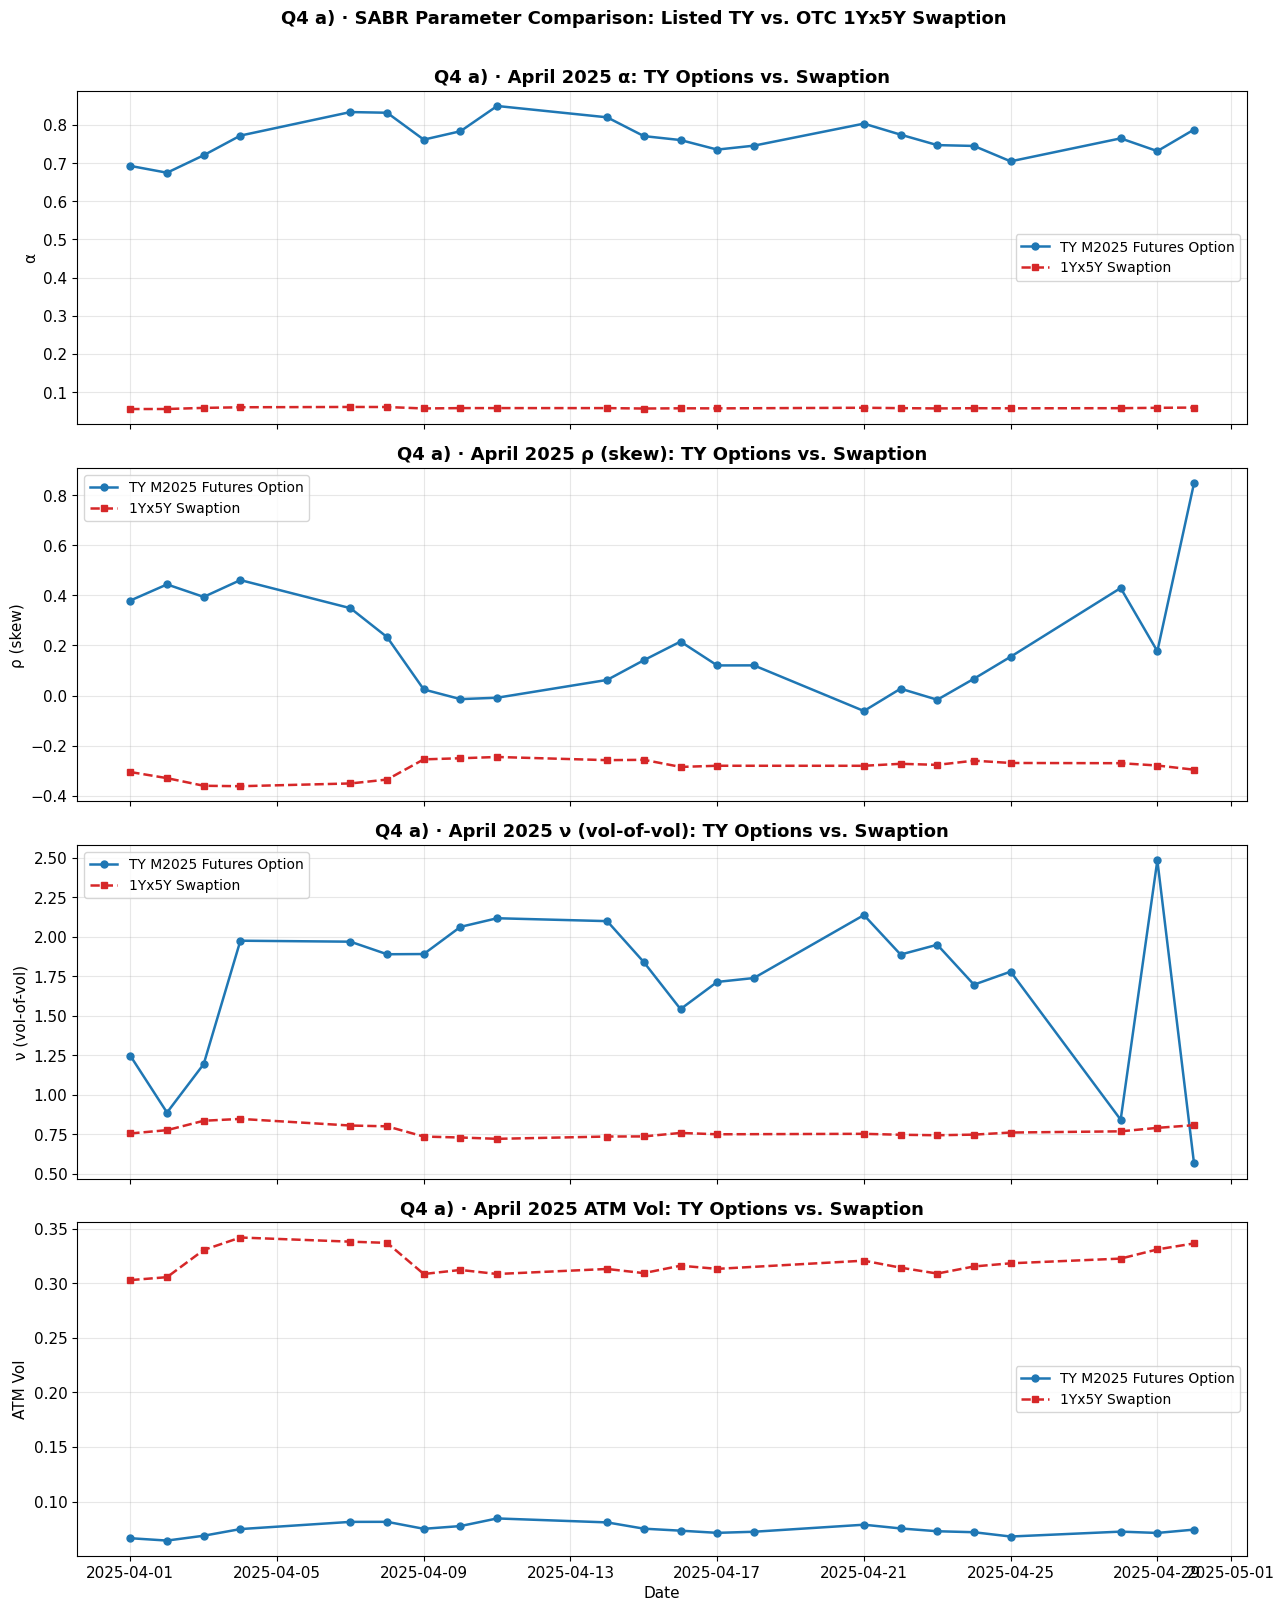

In [17]:
def calibrate_swaptions(beta: float = BETA) -> pd.DataFrame:
    """SABR calibration for each day of the 1Yx5Y swaption smile."""
    sw_mono_cols = [c for c in swaption_smile_black_vol_pct.columns if c != "date"]
    T_sw = 1.0
    records = []

    for dt in swaption_smile_black_vol_pct["date"].sort_values():
        vol_row  = swaption_smile_black_vol_pct[swaption_smile_black_vol_pct["date"] == dt].iloc[0]
        fwd_row  = swaption_smile_atm_forward[swaption_smile_atm_forward["date"] == dt].iloc[0]
        strk_row = swaption_smile_abs_strike_pct[swaption_smile_abs_strike_pct["date"] == dt].iloc[0]

        F       = float(fwd_row["atm_fwd_pct"]) / 100.0
        strikes = np.array([float(strk_row[c]) / 100.0 for c in sw_mono_cols], dtype=float)
        vols    = np.array([float(vol_row[c])   / 100.0 for c in sw_mono_cols], dtype=float)

        # Build pseudo smile_df compatible with calibrate_sabr
        smile_sw = pd.DataFrame({
            "strike":       strikes,
            "vol":          vols,
            "Future_Price": F,
            "T":            T_sw,
        })
        calib = calibrate_sabr(smile_sw, beta=beta)
        records.append({
            "date":      dt,
            "F":         F,
            "T":         T_sw,
            "alpha":     calib["alpha"],
            "beta":      calib["beta"],
            "rho":       calib["rho"],
            "nu":        calib["nu"],
            "sigma_atm": calib["sigma_atm"],
            "rmse":      calib["rmse"],
            "success":   calib["success"],
        })
    return pd.DataFrame(records)


# Calibrate swaption smiles
sabr_sw = calibrate_swaptions()
display(sabr_sw.round(6).style.set_caption(
    "Q4 a) · Swaption SABR Calibration Results (April 2025)"))

# TY M2025 sub-sample for April 2025
ty_apr = (sabr_M2025[
    (sabr_M2025["date"] >= pd.Timestamp("2025-04-01")) &
    (sabr_M2025["date"] <= pd.Timestamp("2025-04-30"))
].copy())

# Time-series overlay
fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=True)
params_4  = [("alpha","α"), ("rho","ρ (skew)"), ("nu","ν (vol-of-vol)"),
             ("sigma_atm","ATM Vol")]
for ax, (p, plabel) in zip(axes, params_4):
    ax.plot(ty_apr["date"],  ty_apr[p],  "o-",
            color="#1f77b4", lw=1.8, ms=5, label="TY M2025 Futures Option")
    ax.plot(sabr_sw["date"], sabr_sw[p], "s--",
            color="#d62728", lw=1.8, ms=5, label="1Yx5Y Swaption")
    ax.set_ylabel(plabel)
    ax.legend()
    ax.set_title(f"Q4 a) · April 2025 {plabel}: TY Options vs. Swaption")
axes[-1].set_xlabel("Date")
fig.suptitle("Q4 a) · SABR Parameter Comparison: Listed TY vs. OTC 1Yx5Y Swaption",
             fontsize=13, fontweight="bold", y=1.005)
fig.tight_layout()
plt.show()

### Q4 b) – Cross-Market Agreement on Large-Move Dates

On the dates with the largest TY parameter changes (identified in Q3b context within
April 2025), we compare the direction and magnitude of swaption $(ν, ρ)$ changes.

,Δν TY,Δρ TY,Score (TY),Δν Swaption,Δρ Swaption
date,,,,,
2025-04-30 00:00:00,-1.920060,0.670410,2.590470,0.016970,-0.016670
2025-04-29 00:00:00,1.643280,-0.252110,1.895390,0.021980,-0.009220
2025-04-28 00:00:00,-0.938240,0.274100,1.212340,0.007640,-0.000880
2025-04-04 00:00:00,0.781660,0.067150,0.848810,0.011770,-0.001800
2025-04-21 00:00:00,0.398830,-0.182050,0.580880,0.002890,-0.000120


,Δν TY,Δρ TY,Score (TY),Δν Swaption,Δρ Swaption,ν agree direction?,ρ agree direction?,ν |SW/TY| ratio,ρ |SW/TY| ratio
date,,,,,,,,,
2025-04-30 00:00:00,-1.920060,0.670410,2.590470,0.016970,-0.016670,✗ No,✗ No,0.009000,0.025000
2025-04-29 00:00:00,1.643280,-0.252110,1.895390,0.021980,-0.009220,✓ Yes,✓ Yes,0.013000,0.037000
2025-04-28 00:00:00,-0.938240,0.274100,1.212340,0.007640,-0.000880,✗ No,✗ No,0.008000,0.003000
2025-04-04 00:00:00,0.781660,0.067150,0.848810,0.011770,-0.001800,✓ Yes,✗ No,0.015000,0.027000
2025-04-21 00:00:00,0.398830,-0.182050,0.580880,0.002890,-0.000120,✓ Yes,✓ Yes,0.007000,0.001000


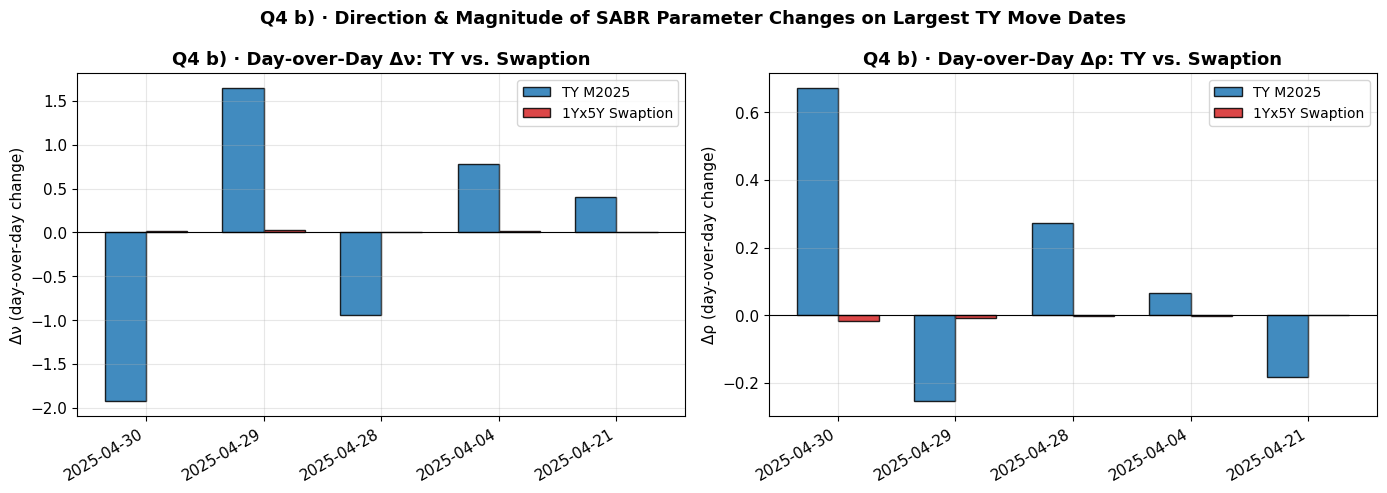

In [18]:
# Swaption day-over-day diffs
sabr_sw_sorted = sabr_sw.sort_values("date").copy()
sabr_sw_sorted["d_nu_sw"]  = sabr_sw_sorted["nu"].diff()
sabr_sw_sorted["d_rho_sw"] = sabr_sw_sorted["rho"].diff()

# TY M2025 diffs on full series; filter to April
sabr_M2025_full = sabr_M2025.sort_values("date").reset_index(drop=True).copy()
sabr_M2025_full["d_nu_ty"]  = sabr_M2025_full["nu"].diff()
sabr_M2025_full["d_rho_ty"] = sabr_M2025_full["rho"].diff()
sabr_M2025_full["score_ty"] = (sabr_M2025_full["d_nu_ty"].abs() +
                                sabr_M2025_full["d_rho_ty"].abs())

ty_apr_sorted = sabr_M2025_full[
    (sabr_M2025_full["date"] >= pd.Timestamp("2025-04-01")) &
    (sabr_M2025_full["date"] <= pd.Timestamp("2025-04-30"))
].copy()

# Top-5 April dates by largest TY parameter jump
top_apr = (ty_apr_sorted.dropna(subset=["score_ty"])
           .nlargest(5, "score_ty")
           [["date", "d_nu_ty", "d_rho_ty", "score_ty"]]
           .reset_index(drop=True))

# Merge with swaption diffs
q4b = top_apr.merge(
    sabr_sw_sorted[["date", "d_nu_sw", "d_rho_sw"]],
    on="date", how="left"
).rename(columns={
    "d_nu_ty":  "Δν TY",
    "d_rho_ty": "Δρ TY",
    "d_nu_sw":  "Δν Swaption",
    "d_rho_sw": "Δρ Swaption",
    "score_ty": "Score (TY)",
})

display(q4b.set_index("date").round(5)
        .style.set_caption(
            "Q4 b) · SABR Parameter Changes on Largest TY Move Dates: "
            "TY vs. Swaption"))

# Direction agreement and magnitude ratios
q4b["ν agree direction?"] = q4b.apply(
    lambda r: ("✓ Yes" if (np.isfinite(r["Δν TY"]) and np.isfinite(r["Δν Swaption"])
                           and np.sign(r["Δν TY"]) == np.sign(r["Δν Swaption"]))
               else ("✗ No" if (np.isfinite(r["Δν TY"]) and np.isfinite(r["Δν Swaption"]))
                     else "n/a")), axis=1)
q4b["ρ agree direction?"] = q4b.apply(
    lambda r: ("✓ Yes" if (np.isfinite(r["Δρ TY"]) and np.isfinite(r["Δρ Swaption"])
                           and np.sign(r["Δρ TY"]) == np.sign(r["Δρ Swaption"]))
               else ("✗ No" if (np.isfinite(r["Δρ TY"]) and np.isfinite(r["Δρ Swaption"]))
                     else "n/a")), axis=1)
q4b["ν |SW/TY| ratio"] = (q4b["Δν Swaption"].abs() / q4b["Δν TY"].abs()).round(3)
q4b["ρ |SW/TY| ratio"] = (q4b["Δρ Swaption"].abs() / q4b["Δρ TY"].abs()).round(3)

display(
    q4b.set_index("date").round(5)
    .style.set_caption(
        "Q4 b) · Direction & Magnitude: TY vs. Swaption\n"
        "(✓ = same direction; |SW/TY| ratio: swaption move relative to TY)")
)

# Bar chart: direction and magnitude
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dates_str = [str(d.date()) for d in q4b["date"]]
x = np.arange(len(dates_str))
w = 0.35

for ax, param, col_ty, col_sw, ylabel in [
    (axes[0], "ν", "Δν TY", "Δν Swaption", "Δν (day-over-day change)"),
    (axes[1], "ρ", "Δρ TY", "Δρ Swaption", "Δρ (day-over-day change)"),
]:
    ty_vals = q4b[col_ty].fillna(0).to_numpy()
    sw_vals = q4b[col_sw].fillna(0).to_numpy()
    ax.bar(x - w/2, ty_vals, w, label="TY M2025",
           color="#1f77b4", edgecolor="black", alpha=0.85)
    ax.bar(x + w/2, sw_vals, w, label="1Yx5Y Swaption",
           color="#d62728", edgecolor="black", alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(dates_str, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Q4 b) · Day-over-Day Δ{param}: TY vs. Swaption")
    ax.legend()

fig.suptitle(
    "Q4 b) · Direction & Magnitude of SABR Parameter Changes on Largest TY Move Dates",
    fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


**Direction:** Only partial agreement — and the disagreements are economically unsurprising. On the five largest TY-move dates in April 2025, direction agreement is **3/5 for ν** and **2/5 for ρ**:
- **ν direction:** agrees on Apr 29, Apr 4, Apr 21; disagrees on Apr 30 and Apr 28.  
- **ρ direction:** agrees on Apr 29 and Apr 21; disagrees on Apr 30, Apr 28, and Apr 4.

Importantly, seeing **opposite signs on ~3 of 5 days** is consistent with structure: TY is quoted in **futures-price vol** while the swaption is quoted in **rate vol**. Because price and rates move inversely (and mapping across “vol spaces” scales roughly like $( \sigma_{\text{price}} \approx \text{Duration}\times F \times \sigma_{\text{rate}} $)), the same underlying rate shock can translate into **different (even flipped) $(\Delta\rho$)** and damped $(\Delta\nu$) when expressed in the other quoting convention.

**Magnitude:** Clear non-agreement. Even when directions match, swaption moves are **tiny** relative to TY moves. The |SW/TY| ratios are generally **~0.1%–3.7% for ρ** and **~0.7%–1.5% for ν** (e.g., Apr 29: ν ratio 0.013, ρ ratio 0.037; Apr 30: ν ratio 0.009, ρ ratio 0.025).

**Bottom line:** The two markets show **weak directional agreement** and **essentially no magnitude agreement** in daily $((\nu,\rho)$) changes on these dates, which is consistent with (i) **price-vol vs rate-vol quoting**, and (ii) different tenor/market structure (listed short-dated TY vs OTC 1Y expiry).

### Q4 c) – Normalised Smile Overlay: TY Options vs. 1Yx5Y Swaptions

For the top-5 April dates (by TY parameter-move magnitude), we overlay
vol/$\sigma_{ATM}$ vs. standardised log-moneyness to compare smile **shape**
(not level) across products.

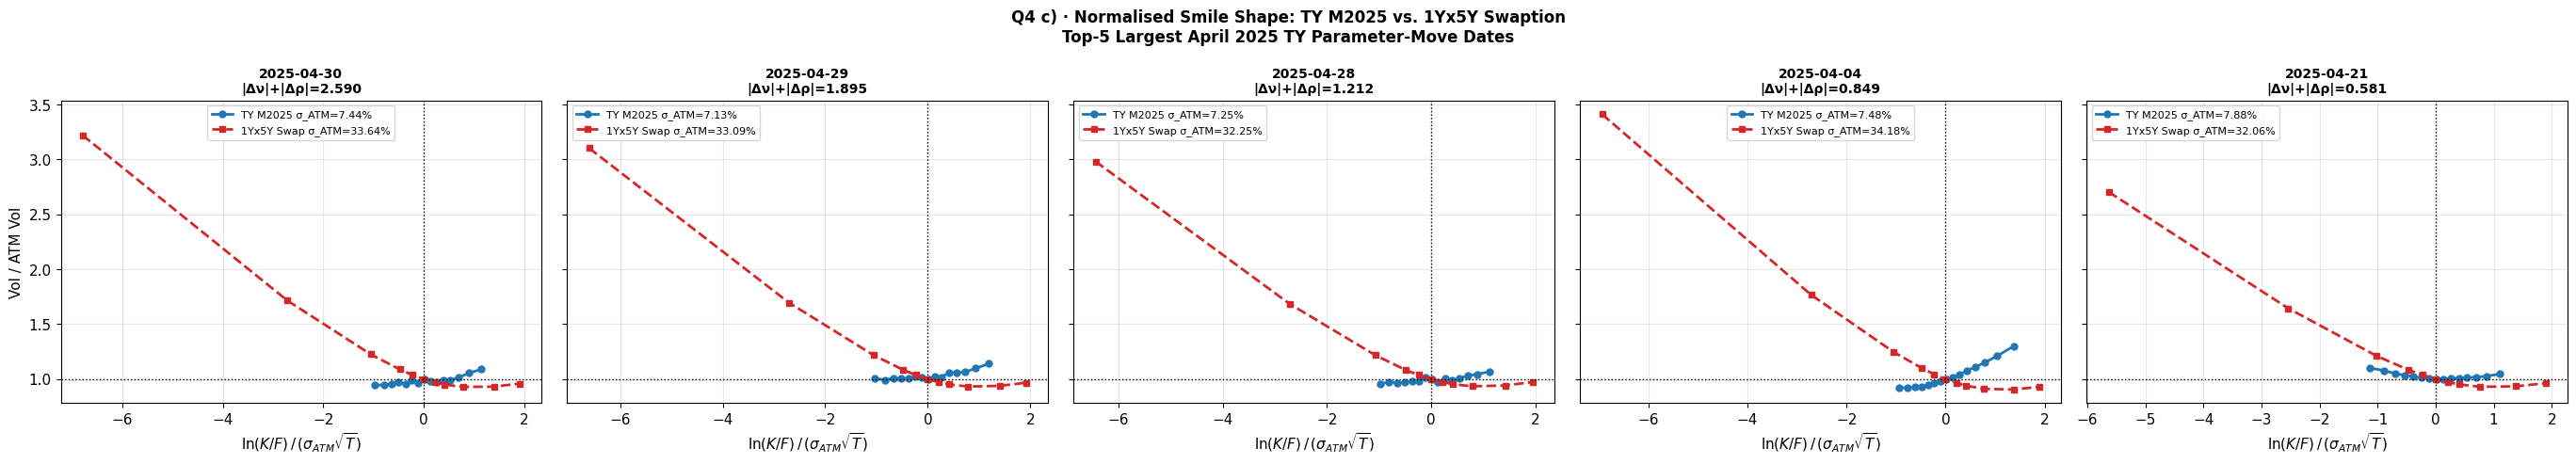

In [19]:
q4c_dates = top_apr["date"].tolist()
n         = len(q4c_dates)
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5), sharey=True)
if n == 1:
    axes = [axes]

sw_avail_dates = swaption_smile_black_vol_pct["date"].values

for ax, dt in zip(axes, q4c_dates):
    score  = float(top_apr.loc[top_apr["date"] == dt, "score_ty"].iloc[0])

    # TY M2025 smile
    ty_rows_dt = ty_option_surfaces_M2025[ty_option_surfaces_M2025["date"] == dt]
    if len(ty_rows_dt) == 0:
        continue
    ty_row  = ty_rows_dt.iloc[0]
    ty_sm   = build_smile(ty_row)
    ty_F_   = float(ty_row["Future Price"])
    ty_T_   = float(ty_row["Expiration Option"])
    ty_atm_ = atm_vol_from_row(ty_row)
    ty_x    = np.log(ty_sm["strike"] / ty_F_) / (ty_atm_ * np.sqrt(ty_T_))
    ty_y    = ty_sm["vol"] / ty_atm_
    ax.plot(ty_x, ty_y, "o-", color="#1f77b4", lw=2, ms=5,
            label=f"TY M2025 σ_ATM={ty_atm_*100:.2f}%")

    # 1Yx5Y swaption smile
    sw_dt = nearest_date(dt, sw_avail_dates)
    if abs((sw_dt - dt).days) <= 2:
        sw_K_, sw_v_, sw_F_, sw_T_, sw_atm_ = build_sw_smile_arrays(sw_dt)
        sw_x = np.log(sw_K_ / sw_F_) / (sw_atm_ * np.sqrt(sw_T_))
        sw_y = sw_v_ / sw_atm_
        ax.plot(sw_x, sw_y, "s--", color="#d62728", lw=2, ms=5,
                label=f"1Yx5Y Swap σ_ATM={sw_atm_*100:.2f}%")

    ax.axhline(1, color="black", ls=":", lw=1)
    ax.axvline(0, color="black", ls=":", lw=1)
    ax.set_title(f"{dt.date()}\n|Δν|+|Δρ|={score:.3f}", fontsize=10)
    ax.set_xlabel(r"$\ln(K/F)\,/\,(\sigma_{ATM}\sqrt{T})$")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Vol / ATM Vol")
fig.suptitle(
    "Q4 c) · Normalised Smile Shape: TY M2025 vs. 1Yx5Y Swaption\n"
    "Top-5 Largest April 2025 TY Parameter-Move Dates",
    fontsize=12, fontweight="bold"
)
fig.tight_layout()
plt.show()

#### Normalised smile shapes: similar, or different tail pricing?

Even after normalising by ATM vol and standardising moneyness, the two markets price **tail risk differently**:

- **Skew direction differs structurally.** TY options show a mild *right-wing richness* in price space (e.g., Q1c normalised 25Δ RR is negative on Apr 2/3: −0.0966, −0.1208), while the 1Yx5Y swaption shows *left-wing richness* in rate space (normalised 25Δ RR positive: +0.0753, +0.0790). This indicates opposite directional tail premia once expressed in each product’s native quoting convention.

### Q4 d) – Reasons for Cross-Product Differences

The differences are structural:

1) **Quoting / underlying variable (price vol vs rate vol).** TY vols are quoted on **futures price**, swaptions on **rates**. With $(P \downarrow$) when $(r \uparrow$), and the rough mapping $( \sigma_{\text{price}} \approx \text{Duration} \times F \times \sigma_{\text{rate}} $), the same rate-risk distribution can imply **different (even flipped) skew/ρ** when expressed in price space versus rate space.

2) **Tenor.** TY options here are short-dated (front contract), while the swaption is **1Y expiry**. Short expiries are much more sensitive to near-term event risk and flow, so their **ν (curvature) and ρ (skew)** can reprice sharply day-to-day; the 1Y swaption smooths that.

3) **Market structure / liquidity.** TY options are **listed**, high-frequency price discovery with concentrated strike liquidity; swaptions are **OTC dealer-quoted**, with balance-sheet/flow effects and typically smoother day-over-day parameter moves.

4) **Instrument-specific mechanics.** Treasury futures embed delivery/CTD and futures microstructure; swaptions reference a swap rate and reflect a different hedging clientele (e.g., mortgage/ALM flow), which can persistently weight one tail more than the other.

## Question 5 – Practical Implications: Augmented Delta Across Regimes

**Setup:** A dealer is short a put on TY futures struck 50 basis points below ATM:
$K = F - 0.50$ (0.5 futures-price points).

**Black put delta (signed):**
$$\Delta_{\text{Black}} = N(d_1) - 1, \quad
d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$$

**SABR augmented delta (Hagan et al.):**
$$\Delta_{\text{SABR}} = \Delta_{\text{Black}} + V \cdot \frac{\partial\sigma}{\partial F}$$

where $V = F \cdot \varphi(d_1)\sqrt{T}$ is Black vega and $\partial\sigma/\partial F$
is computed by **central finite difference** with bump $\varepsilon = 10^{-4}$:
$$\frac{\partial\sigma}{\partial F} \approx
\frac{\sigma_B(F+\varepsilon,K) - \sigma_B(F-\varepsilon,K)}{2\varepsilon}$$

### Q5 a) – Black Delta and SABR Augmented Delta: Volatile vs. Calm Regime

Volatile date: the M2025 date with highest ATM vol (inside the April 2025 tariff episode).
Calm date: the M2025 date with the lowest ATM vol from the stable, low-change-score half
(excluding near-expiry T < 0.05 yr).

In [20]:
# ── Q5 helper functions (defined here) ────────────────────────────────────────

def black_greeks(F: float, K: float, sigma: float, T: float) -> dict:
    """Black-76 put delta and vega (undiscounted, futures convention)."""
    if sigma <= 0 or T <= 0 or K <= 0:
        return {"d1": np.nan, "delta_black": np.nan, "vega": np.nan}
    d1    = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    delta = norm.cdf(d1) - 1.0       # signed put delta: N(d1) – 1
    vega  = F * norm.pdf(d1) * np.sqrt(T)
    return {"d1": d1, "delta_black": delta, "vega": vega}


def sabr_augmented_delta(F: float, K: float, T: float,
                          alpha: float, beta: float, rho: float, nu: float,
                          eps: float = 1e-4) -> dict:
    """
    SABR augmented put delta via central finite difference on F.
    ∂σ/∂F ≈ [σ_B(F+ε, K) – σ_B(F–ε, K)] / (2ε)
    Correction term: V · ∂σ/∂F  (vega times vol sensitivity to F)
    """
    sigma_mid = sabr_implied_vol(F,        K, T, alpha, beta, rho, nu)
    sigma_up  = sabr_implied_vol(F + eps,  K, T, alpha, beta, rho, nu)
    sigma_dn  = sabr_implied_vol(F - eps,  K, T, alpha, beta, rho, nu)

    if not all(np.isfinite([sigma_mid, sigma_up, sigma_dn])):
        return {"delta_black": np.nan, "delta_sabr": np.nan, "correction": np.nan,
                "sigma": np.nan, "dsigma_dF": np.nan, "vega": np.nan,
                "F": F, "K": K, "T": T, "alpha": alpha, "rho": rho, "nu": nu}

    dsigma_dF  = (sigma_up - sigma_dn) / (2.0 * eps)
    gr         = black_greeks(F, K, sigma_mid, T)
    correction = gr["vega"] * dsigma_dF
    delta_sabr = gr["delta_black"] + correction

    return {
        "sigma":       sigma_mid,
        "dsigma_dF":   dsigma_dF,
        "vega":        gr["vega"],
        "delta_black": gr["delta_black"],
        "correction":  correction,
        "delta_sabr":  delta_sabr,
        "F": F, "K": K, "T": T, "alpha": alpha, "rho": rho, "nu": nu,
    }


# ── Select volatile and calm dates ────────────────────────────────────────────
sabr_M2025_clean = sabr_M2025.dropna(subset=["sigma_atm", "rho", "nu", "alpha"])

# Volatile: highest ATM vol in M2025
volatile_row  = sabr_M2025_clean.loc[sabr_M2025_clean["sigma_atm"].idxmax()]
volatile_date = volatile_row["date"]

# Calm: lowest ATM vol among low-score-change days, excluding near-expiry (T < 0.05)
m2025_w_score = sabr_M2025_clean.sort_values("date").copy()
m2025_w_score["d_nu"]  = m2025_w_score["nu"].diff()
m2025_w_score["d_rho"] = m2025_w_score["rho"].diff()
m2025_w_score["score"] = m2025_w_score["d_nu"].abs() + m2025_w_score["d_rho"].abs()
calm_pool = m2025_w_score[
    (m2025_w_score["score"] <= m2025_w_score["score"].quantile(0.50)) &
    (m2025_w_score["T"] > 0.05)
]
calm_row  = calm_pool.loc[calm_pool["sigma_atm"].idxmin()]
calm_date = calm_row["date"]

# Display selected dates
display(pd.DataFrame({
    "Type":        ["Volatile", "Calm"],
    "Date":        [volatile_date.date(), calm_date.date()],
    "ATM Vol (%)": [round(float(volatile_row["sigma_atm"]) * 100, 4),
                    round(float(calm_row["sigma_atm"]) * 100, 4)],
    "T (yrs)":     [round(float(volatile_row["T"]), 4),
                    round(float(calm_row["T"]), 4)],
    "ρ":           [round(float(volatile_row["rho"]), 4),
                    round(float(calm_row["rho"]), 4)],
    "ν":           [round(float(volatile_row["nu"]), 4),
                    round(float(calm_row["nu"]), 4)],
}).style.set_caption("Q5 a) · Volatile and Calm Dates"))


def compute_deltas_for_date(dt: pd.Timestamp,
                             sabr_df: pd.DataFrame,
                             surface_df: pd.DataFrame) -> dict:
    """Compute Black and SABR augmented delta for a given date."""
    cal  = sabr_df[sabr_df["date"] == dt].iloc[0]
    surf = surface_df[surface_df["date"] == dt].iloc[0]
    F = float(surf["Future Price"])
    T = float(surf["Expiration Option"])
    K = F - 0.50    # 50 bp below ATM in futures-price space
    out = sabr_augmented_delta(
        F, K, T,
        alpha=float(cal["alpha"]), beta=BETA,
        rho=float(cal["rho"]), nu=float(cal["nu"])
    )
    out["date"]      = dt
    out["sigma_atm"] = float(cal["sigma_atm"])
    return out


res_volatile = compute_deltas_for_date(
    volatile_date, sabr_M2025, ty_option_surfaces_M2025)
res_calm     = compute_deltas_for_date(
    calm_date,     sabr_M2025, ty_option_surfaces_M2025)

q5_df = pd.DataFrame([res_volatile, res_calm]).set_index("date")
display(
    q5_df[["F", "K", "T", "sigma_atm", "alpha", "rho", "nu",
           "sigma", "delta_black", "vega", "dsigma_dF",
           "correction", "delta_sabr"]]
    .round(6)
    .style.set_caption("Q5 a) · Black vs. SABR Augmented Put Delta (K = F – 0.50)")
)

,Type,Date,ATM Vol (%),T (yrs),ρ,ν
0,Volatile,2025-04-11,8.459100,0.115600,-0.008400,2.117600
1,Calm,2025-03-24,6.029600,0.165000,0.254200,1.268700


,F,K,T,sigma_atm,alpha,rho,nu,sigma,delta_black,vega,dsigma_dF,correction,delta_sabr
date,,,,,,,,,,,,,
2025-04-11 00:00:00,109.734375,109.234375,0.115644,0.084591,0.849439,-0.008353,2.117584,0.084929,-0.431497,14.667214,0.000683,0.010017,-0.421479
2025-03-24 00:00:00,110.546875,110.046875,0.164959,0.060296,0.621292,0.254183,1.268683,0.059706,-0.421107,17.560614,-0.001267,-0.022251,-0.443357


### Q5 b) – Hedge-Ratio Correction: Magnitude and Economic Significance

,Date,ATM Vol (%),σ(K) SABR (%),Δ_Black,Δ_SABR,Correction (V · ∂σ/∂F),∂σ/∂F,Correction % of |Δ_Black|
Regime,,,,,,,,
Volatile,2025-04-11,8.459150,8.492948,-0.431497,-0.421479,0.010017,0.000683,2.321533
Calm,2025-03-24,6.029550,5.970648,-0.421107,-0.443357,-0.022251,-0.001267,-5.283886


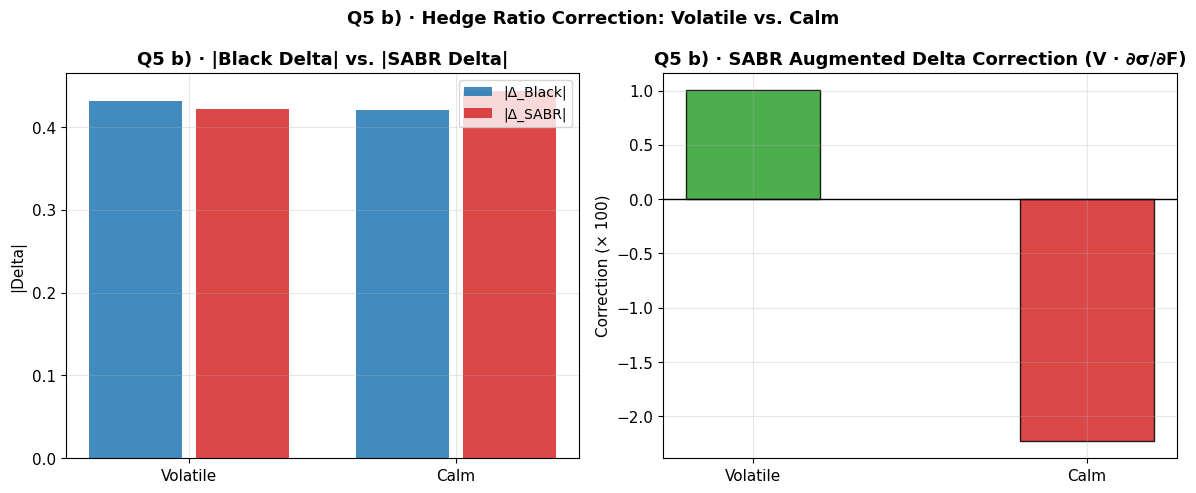

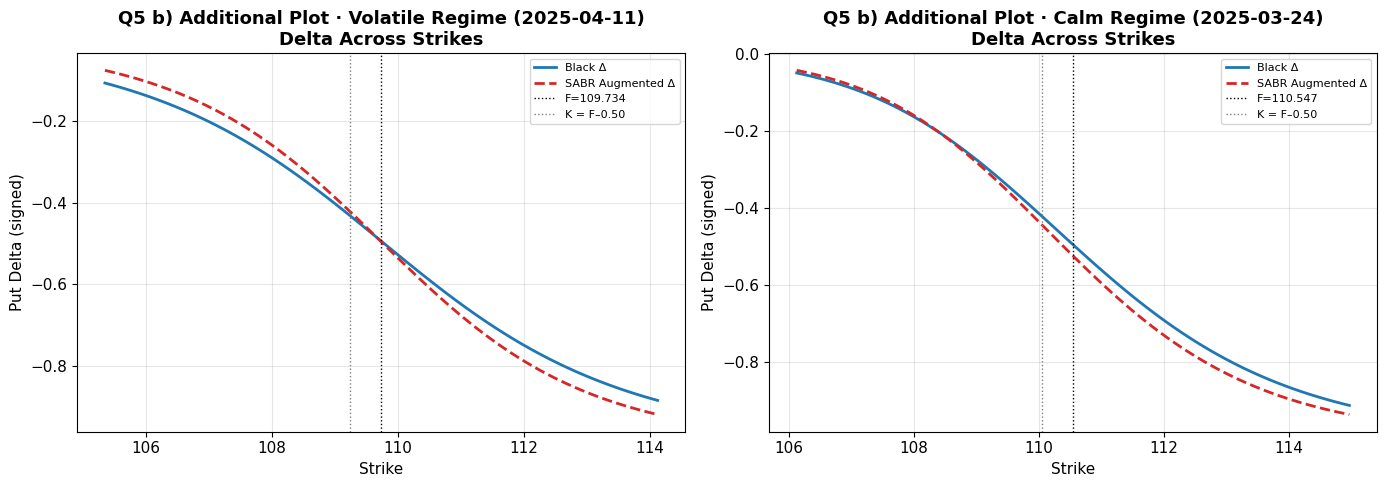

In [21]:
q5b = pd.DataFrame({
    "Regime":   ["Volatile", "Calm"],
    "Date":     [volatile_date.date(), calm_date.date()],
    "ATM Vol (%)":                [res_volatile["sigma_atm"] * 100,
                                   res_calm["sigma_atm"] * 100],
    "σ(K) SABR (%)":             [res_volatile["sigma"] * 100,
                                   res_calm["sigma"] * 100],
    "Δ_Black":                   [res_volatile["delta_black"],  res_calm["delta_black"]],
    "Δ_SABR":                    [res_volatile["delta_sabr"],   res_calm["delta_sabr"]],
    "Correction (V · ∂σ/∂F)":   [res_volatile["correction"],   res_calm["correction"]],
    "∂σ/∂F":                     [res_volatile["dsigma_dF"],    res_calm["dsigma_dF"]],
    "Correction % of |Δ_Black|": [
        res_volatile["correction"] / abs(res_volatile["delta_black"]) * 100
        if abs(res_volatile["delta_black"]) > 0 else np.nan,
        res_calm["correction"]     / abs(res_calm["delta_black"]) * 100
        if abs(res_calm["delta_black"])     > 0 else np.nan,
    ],
})

display(q5b.set_index("Regime").round(6)
        .style.set_caption(
            "Q5 b) · SABR Hedge Ratio Correction vs. Black Delta: "
            "Volatile vs. Calm Regime"))

# Additional Plot: Visual comparison of delta decomposition ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

regimes   = ["Volatile", "Calm"]
deltas_b  = [res_volatile["delta_black"], res_calm["delta_black"]]
deltas_s  = [res_volatile["delta_sabr"],  res_calm["delta_sabr"]]
corr_vals = [res_volatile["correction"],  res_calm["correction"]]

ax = axes[0]
x  = np.arange(2)
ax.bar(x - 0.2, [abs(d) for d in deltas_b], 0.35,
       label="|Δ_Black|", color="#1f77b4", alpha=0.85)
ax.bar(x + 0.2, [abs(d) for d in deltas_s], 0.35,
       label="|Δ_SABR|",  color="#d62728", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(regimes)
ax.set_ylabel("|Delta|")
ax.set_title("Q5 b) · |Black Delta| vs. |SABR Delta|")
ax.legend()

ax = axes[1]
ax.bar(x, [c * 100 for c in corr_vals], 0.4,
       color=["#d62728" if c < 0 else "#2ca02c" for c in corr_vals],
       alpha=0.85, edgecolor="black")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(regimes)
ax.set_ylabel("Correction (× 100)")
ax.set_title("Q5 b) · SABR Augmented Delta Correction (V · ∂σ/∂F)")

fig.suptitle("Q5 b) · Hedge Ratio Correction: Volatile vs. Calm",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

# Additional Plot: Delta profile across the full strike range for each regime ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res, label_date, regime in [
    (axes[0], res_volatile, volatile_date.date(), "Volatile"),
    (axes[1], res_calm,     calm_date.date(),     "Calm"),
]:
    F_     = res["F"]
    T_     = res["T"]
    a_     = res["alpha"]
    rho_   = res["rho"]
    nu_    = res["nu"]
    K_grid = np.linspace(F_ * 0.96, F_ * 1.04, 80)
    db_arr, ds_arr = [], []
    for K_ in K_grid:
        sig_ = sabr_implied_vol(F_, K_, T_, a_, BETA, rho_, nu_)
        if not np.isfinite(sig_):
            db_arr.append(np.nan); ds_arr.append(np.nan)
            continue
        gr_  = black_greeks(F_, K_, sig_, T_)
        db_arr.append(gr_["delta_black"])
        out_ = sabr_augmented_delta(F_, K_, T_, a_, BETA, rho_, nu_)
        ds_arr.append(out_["delta_sabr"])

    ax.plot(K_grid, db_arr, "-",  color="#1f77b4", lw=2, label="Black Δ")
    ax.plot(K_grid, ds_arr, "--", color="#d62728", lw=2, label="SABR Augmented Δ")
    ax.axvline(F_,        color="black", ls=":", lw=1, label=f"F={F_:.3f}")
    ax.axvline(F_ - 0.50, color="grey",  ls=":", lw=1, label="K = F–0.50")
    ax.set_title(f"Q5 b) Additional Plot · {regime} Regime ({label_date})\nDelta Across Strikes")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Put Delta (signed)")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

#### When does the SABR correction matter most for hedging?

The SABR (augmented) delta correction becomes most economically significant when the slope of the volatility smile at the hedge strike is steep; not simply when market volatility is high. In practical terms, this means the size and even the direction of the correction depend on how sharply implied volatility changes with futures price (captured by SABR’s ρ and ν parameters), rather than just on the level of ATM vol.

**Intuition:** Many would expect that higher volatility markets (“stress” regimes) naturally lead to larger hedge corrections due to bigger price swings. In reality, our results show that the *shape* of the smile matters more: when the local slope (∂σ/∂F) is steep at the hedge strike, even a calm market can produce a large SABR correction.

**What did we find?**
 - On the highly volatile 2025‑04‑11 (ATM vol 8.5%), the SABR correction was **+2.3%** of the Black delta—a modest adjustment.
 - On the much calmer 2025‑03‑24 (ATM vol 6.0%), the correction jumped to **−5.3%**—more than twice as large in absolute size, but in the opposite direction.

**Why?** Because on the calm date, the smile was actually *steeper* at the hedge strike, so the delta correction was larger and negative. This highlights that the risk of using a flat Black delta does not only grow in volatile regimes; it can be substantial in quiet periods if the smile’s shape changes.

**Bottom line:** The magnitude and sign of the delta correction are driven by local smile dynamics, not just market volatility. Relying on simple Black delta hedging misses this nuance, exposing traders to hidden model risk whenever the underlying smile is steep or unstable even in markets that appear calm on the surface.

### Q5 c) – Implications for Hedging and Recalibration Policy

Using flat Black delta in quiet markets is effectively assuming $( \partial\sigma/\partial F \approx 0$). Our results show that assumption can be wrong even in calm periods: on 2025‑03‑24 the correction is **−5.28% of $(|Δ_{Black}|$)**.

When the regime shifts, the risks compound:
- **Sign and magnitude can change quickly.** The correction depends on local smile slope (ρ/ν). If ρ (and sometimes ν) moves or flips sign, the augmented correction can **change sign**, turning an under-hedge into an over-hedge (or vice versa).
- **Stale parameters are costly fast (Q3d).** Holding $((\nu,\rho)$) fixed for just **5 days** adds **~6–15 bp RMSE** (and much more at 10–20 days). If a desk “waits to recalibrate until things move,” it will carry the **stale shape** precisely when the smile is re-anchoring.
- **Operational implication:** flat Black delta may look harmless in a quiet window, but it leaves the desk exposed to **model-driven delta slippage** that materialises exactly during regime transitions — when hedging accuracy matters most.

## Summary

### SABR across volatility regimes.
The key distinction in TY futures options is not simply “high vol vs. low vol,” but rather **stable vs. unstable smile**. We find that SABR fits are actually *better* (lower RMSE) when ATM volatility is high: the correlation between ATM vol and RMSE is negative and statistically significant for H2026 (r = −0.44, p < 0.001), and also negative for M2025 (r = −0.26, p ≈ 0.05).

The model's main weakness occurs **near expiry**, when the smile becomes highly sensitive to small wing quote changes; in these cases, calibration can become unstable and the parameters (especially ρ, ν) may be pushed to boundaries (e.g., ρ ≈ −1, ν very large). Outlier RMSE dates cluster in such periods (e.g., late M2025, Feb H2026). This highlights a practical limitation: as time to expiry $(T \to 0$), SABR may end up fitting microstructure noise, so calibrations for option contracts near expiration must be viewed with caution.

### Listed TY vs. OTC swaptions.
The two markets consistently price tail risk **differently**, even after normalising for vol level and moneyness. TY options, quoted in **price volatility**, and swaptions, quoted in **rate volatility**, display structurally different skews: TY smiles tend to be positively skewed (right-wing elevated, positive ρ), while swaptions persistently show negative skew (left-wing elevated, negative ρ). This sign flip reflects the price/rate duality: as the futures price moves inversely to rates, mapping price vol to rate vol can invert the skew.

TY smiles can also develop substantial, state-dependent curvature (e.g., after the policy pause), while swaption smiles remain almost linear with less curvature. Cross-market co-movement in daily smile parameters is weak: even on large TY move dates, ν and ρ move together in direction only about half the time, and swaption parameter moves are just a few percent of those for TYs.

### When does model flexibility matter most for hedging?
The economically material hedge correction depends on **local smile slope**, not just headline volatility. For example, in a delta hedge at $(K=F-0.50$), the SABR correction was −5.3% of |Δ₍Black₎| in a calm regime (2025-03-24), but only +2.3% in a volatile regime (2025-04-11), because the smile slope $(\partial \sigma/\partial F$) was much steeper in the calm period. This means the risk of using flat Black delta is not just higher in volatile regimes; it can spike even in quiet periods if the smile shape changes.

Moreover, (ν, ρ) parameters go stale quickly. 5 days of staleness adds **6–15 bp RMSE**, and the risk is largest when the smile is actively re-anchoring during regime shifts. As a result, frequent recalibration and use of the SABR delta (not just Black) is essential, especially when skew and curvature are moving, regardless of the volatility regime.

### End note (assumptions / interpretation).

Results are conditional on a SABR(β=0.5) calibration using the Hagan implied-vol approximation and a vol-RMSE objective.

Cross-market comparisons (TY vs 1Yx5Y) are not fully apples-to-apples because TY vols are quoted in futures-price space while swaptions are rate vols, and the products differ in tenor and market structure.

### Use of AI
 
Generative AI tools were used during the development and preparation of this notebook. Specifically, **ChatGPT** and **Claude** was utilized to assist broadly in coding productivity, code review, and code refactoring. AI was most helpful in:
 
 - Refining and structuring Python routines for SABR calibration, diagnostics, and visualizations
 - Assisting with the automation of data processing and exploratory analysis workflows
 
All AI-generated code were reviewed and thoughtfully validated for accuracy and correctness before inclusion. Conclusions and quantitative results were independently verified by cross & sanity checking calculations (whenever possible), reviewing plots, and manually examining model outputs.